#### Importing libraries and defining functions

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def LF_step(q,p,a,dt,i,**kwargs):
    q_mid = q[i] + p[i]*dt/2
    p[i+1] = p[i] + a(q_mid,**kwargs)*dt
    q[i+1] = q_mid + p[i+1]*dt/2

def LFTT_step(W,t,q,p,a,dt,i,**kwargs): # "dt" is actually ds
    q_mid = q[i] + p[i]*(dt/2)/W[i]
    t_mid = t[i] + (dt/2)/W[i]
    q_mid_mag = np.linalg.norm(q_mid)
    p[i+1] = p[i] + a(q_mid,**kwargs)*dt*q_mid_mag
    W[i+1] = W[i] - np.dot(q_mid, ((p[i+1] + p[i])/2))*dt*(q_mid_mag**-2)
    q[i+1] = q_mid + p[i+1]*(dt/2)/W[i+1]
    t[i+1] = t_mid + (dt/2)/W[i+1]

def LF_adaptive_step(t,q,p,a,dt,i,**kwargs):
    r = np.linalg.norm(q[i])
    dt_new = dt * r 
    q_mid = q[i] + p[i]*(dt_new/2)
    # t_mid = t[i] + (dt/2)*r
    # q_mid_mag = np.linalg.norm(q_mid)
    p[i+1] = p[i] + a(q_mid,**kwargs)*dt_new
    # W[i+1] = W[i] - np.dot(q_mid, ((p[i+1] + p[i])/2))*dt*(q_mid_mag**-2)
    q[i+1] = q_mid + p[i+1]*(dt_new/2)
    t[i+1] = t[i] + dt_new


GM_s = 4*(np.pi**2) # the GM values for sun in AU^3 year^-2
plt.rcParams['ytick.labelsize'] = 8


def gravity(r,GM=GM_s,delta=0,lamb=0):
    if lamb == 0: return - GM*r/(np.linalg.norm(r)**(3+delta))
    else: 
        r_mag = np.linalg.norm(r)
        return -GM*r*(r_mag**-(3+delta) + lamb*r_mag**-(5+delta))

def Orbit(
    GM=GM_s,
    r_init=np.array([1.017, 0.0]),
    v_init=np.array([0.0,6.179]),
    methods = {"LF":0.001},
    deltas =[0],
    lambs = [0],
    T_max = 5, # years
    a = gravity,
    vis=False,vis_prec=False
    ):
    if vis:
        fig = plt.figure(figsize=(10,20))
        AX = fig.subplots(15,1,sharex=True)
        fig2 = plt.figure()
        AX2 = fig2.subplots(1,1)
    if vis_prec:
        fig3 = plt.figure()
        AX3 = fig3.subplots(1,1)
    colors = ["blue","red","green","black","purple","yellow","brown"][::-1]

    precession_phi = {}
    precession_phi_regression = {}
    precession_phi_regression_R2 = {}
    precession_theta_r_min = {}
    precession_theta_r_min_regression = {}
    precession_theta_r_min_regression_R2 = {}
    for delta in deltas:
        for method, dt in methods.items():
            for lamb in lambs:
                if vis or vis_prec: c = colors.pop()
                t = np.arange(0,T_max+dt/2,dt)
                r = np.zeros((t.shape[0],2))
                v = np.zeros((t.shape[0],2))
                r[0] = r_init
                v[0] = v_init
                if method=="LF":
                    for i in range(t.shape[0]-1):
                        LF_step(r,v,gravity,dt,i,lamb=lamb,delta=delta)
                elif method=="LFTT":
                    W = np.zeros_like(t)
                    W[0] = 1/np.linalg.norm(r_init)
                    for i in range(t.shape[0]-1):
                        LFTT_step(W,t,r,v,gravity,dt,i,lamb=lamb,delta=delta)
                elif method=="LFAS":
                    for i in range(t.shape[0]-1):
                        LF_adaptive_step(t,r,v,gravity,dt,i,lamb=lamb,delta=delta)
                else: raise ValueError(f"unknown method: {method}")
                x = r[:,0]
                y = r[:,1]
                v_x = v[:,0]
                v_y = v[:,1]
                theta = np.arctan2(y,x)
                theta = theta + 2*np.pi*(theta <  0)
                r = (x**2 + y**2)**0.5
                v = (v_x**2 + v_y**2)**0.5
                E = 0.5*v**2 - GM/(r*(1+delta))
                L = x*v_y - y*v_x
                A_x,A_y = [L*v_y -GM*x/r,-L*v_x -GM*y/r]
                A = (A_x**2 + A_y**2)**0.5
                phi = np.arctan2(A_y,A_x)
                phi = 2*np.pi*(phi < 0) + phi
                v_r = (x*v_x + y*v_y)/r
                v_theta = (-y*v_x + x*v_y)/r
                omega = v_theta/r
                a = ((2/r) - ((v**2)/GM))**-1
                T = 2*np.pi*((a**3)/GM)**0.5 
                r_prev = np.concatenate((r[:1],r[:-1]))
                r_next = np.concatenate((r[1:],r[-1:]-1e-12))
                i_r = np.flatnonzero((r < r_prev) & (r <= r_next))
                theta_prev = np.concatenate((theta[:1],theta[:-1]))
                theta_next = np.concatenate((theta[1:],theta[-1:]))
                i_theta = np.flatnonzero((theta < theta_prev) & (theta <= theta_next))
                n_r = np.zeros_like(t,dtype=int)
                for i in i_r :
                    n_r = n_r + (np.arange(t.shape[0]) >= i)
                n_theta = np.zeros_like(t,dtype=int)
                for i in i_theta :
                    n_theta = n_theta + (np.arange(t.shape[0]) >= i)
                # n_theta = n_theta + theta/(2*np.pi)
                cond = (
                    f"({method}, " +
                    r"$\delta={" + str(delta)+ 
                    r"}$, $\Delta t=" + str(dt) + 
                    r"$, $\lambda=" + str(lamb)+"$)")

                precession_theta_r_min[cond] = (theta[i_r][-1]-theta[i_r][0])/(t[i_r][-1]-t[i_r][0])
                precession_phi[cond] = (phi[-1]-phi[0])/(t[-1]-t[0])

                X = np.vstack((n_theta[i_r],np.ones_like(n_theta[i_r]))).T

                param,res,rk,s = np.linalg.lstsq(X,theta[i_r],rcond=None)
                pred = np.dot(X,param)
                R2 = 1- (res[0]/X.shape[0])/(theta[i_r].var())

                param_phi,res,rk,s = np.linalg.lstsq(X,phi[i_r],rcond=None)
                pred_phi = np.dot(X,param_phi)
                R2_phi = 1- (res[0]/X.shape[0])/(phi[i_r].var())

                if vis_prec:
                    AX3.plot(n_theta[i_r],theta[i_r],'o',label=r"$\theta_{r_{min}}$ " + cond, color=c)
                    AX3.plot(n_theta[i_r],phi[i_r],'*',label=r"$\phi$ " + cond, color=c)
                    AX3.plot(n_theta[i_r],pred,":",label=r"fitted line for $\theta_{r_{min}}$ " + cond, color=c)
                    AX3.plot(n_theta[i_r],pred_phi,"-",label=r"fitted line for $\phi$ " + cond, color=c)
                
                precession_theta_r_min_regression[cond] = param[0]
                precession_theta_r_min_regression_R2[cond] = R2
                precession_phi_regression[cond] = param_phi[0]/(t[-1]-t[0])
                precession_phi_regression_R2[cond] = R2_phi

                if not vis:continue
                AX[0].plot(t,v_x,label=cond,color=c) 
                AX[1].plot(t,v_y,label=cond,color=c)
                AX[2].plot(t,theta,label=cond,color=c)
                AX[2].plot(t[i_theta],theta[i_theta],'o',label="minima " + cond,color=c)
                AX[3].plot(t,r,label=cond,color=c)
                AX[3].plot(t[i_r],r[i_r],'o',label="minima " + cond,color=c)
                AX[4].plot(t,v,label=cond,color=c)
                AX[5].plot(t,v_r,label=cond,color=c)
                AX[6].plot(t,omega,label=cond,color=c)
                AX[7].plot(t,n_r,label=cond,color=c)
                AX[8].plot(t,n_theta,label=cond,color=c)
                AX[9].plot(t,E,label=cond,color=c)
                AX[10].plot(t,L,label=cond,color=c)
                AX[11].plot(t,A,label=cond,color=c)
                AX[12].plot(t,phi,label=cond,color=c)
                AX[13].plot(t[i_r],theta[i_r],'-o',label=cond)
                AX[14].plot(t[i_theta+1], (n_r[i_theta+1]/n_theta[i_theta+1]),'-o',label=cond)

                AX2.plot(x,y,label=cond,color=c)
                AX2.plot(x[0],y[0],'o',label="initial position" + cond,color=c)

    if vis:
        AX[2].set_ylim(0,2*np.pi)
        AX[2].set_yticks([0,2*np.pi],[0,r"$2\pi$"])
        AX[2].legend()
        AX[7].legend()
        AX[8].legend()
        AX[12].set_ylim(0,2*np.pi)
        AX[12].set_yticks([0,2*np.pi],[0,r"$2\pi$"])
        AX[13].set_ylim(0,2*np.pi)
        AX[13].set_yticks([0,2*np.pi],[0,r"$2\pi$"])
        ylabels = ["v_x","v_y",r"\theta","r","v","v_r",r"\omega",r"n_r",r"n_\theta",r"E/m",r"L/m",r"A/m^2",r"\phi",
        r"\theta_{r_{min}}",r"n_r/n_\theta"]
        for ax,lbl in zip(AX,ylabels): 
            ax.set_ylabel("$" + lbl + "$")
            # ax.legend()

        # AX[12].set_xlabel("$t$ (years)")
        AX[12].legend()
        AX[13].legend()
        AX[14].legend()
        AX[14].set_xlabel(r"$t$ (years)")

        AX2.set_xlabel("$x$ (AU)")
        AX2.set_ylabel("$y$ (AU)")
        AX2.plot([0],[0],'o',label="sun",color="yellow",markersize=10)
        AX2.axhline(0)
        AX2.axvline(0)
        AX2.set_aspect('equal')
        AX2.set_xlim(-0.1-np.linalg.norm(r_init),0.1+2*np.linalg.norm(r_init))
        AX2.set_ylim(-0.1-np.linalg.norm(r_init),0.1+2*np.linalg.norm(r_init))
        AX2.legend()
    
    if vis_prec:
        AX3.legend()
        AX3.set_xlabel(r"$n_\theta$")
        AX3.set_ylabel(r"$\theta_p$")

    return (
        precession_theta_r_min,
        precession_theta_r_min_regression,
        precession_theta_r_min_regression_R2,
        precession_phi,
        precession_phi_regression,
        precession_phi_regression_R2
        )


## Mini-Project 1 : Closed and Open Orbits in Modified Gravity

### Parts 1 and 2: Earth-Sun system with standard LF

For a given accelleration $\vec a(\vec q)$, the position-verlet LF integrator does :

$$
\vec q_{t+\Delta t/2} = \vec q_{t} + \vec p_t \Delta t/2 \\
\vec p_{t+\Delta t} = \vec p_{t} + \vec a(\vec q_{t+\Delta t/2})\Delta t\\
\vec q_{t} = \vec q_{t+\Delta t/2} + \vec p_{t+\Delta t} \Delta t/2 
$$

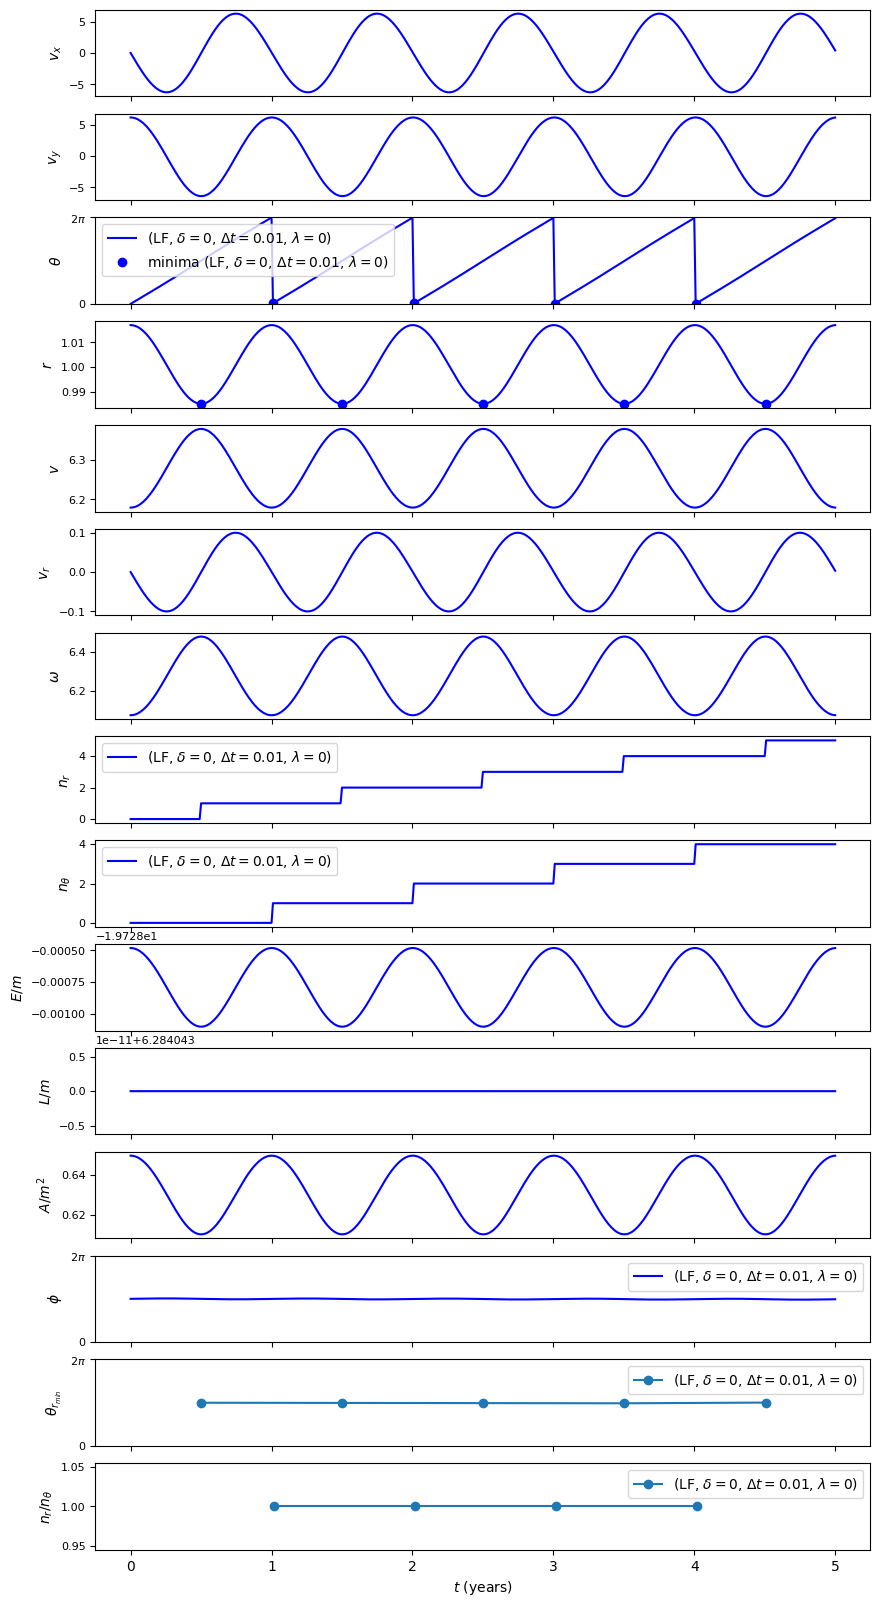

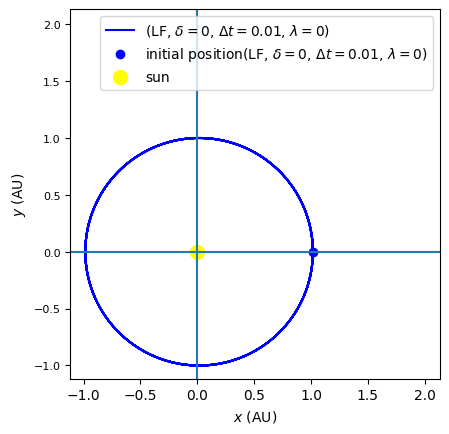

In [22]:
Orbit(vis=True,T_max=5,deltas=[0],methods={"LF":0.01},
    r_init=np.array([1.017, 0.0]), # AU
    v_init=np.array([0.0,6.179]) # AU/year
)
plt.show()

### Parts 3 and 4 : Closed Orbits

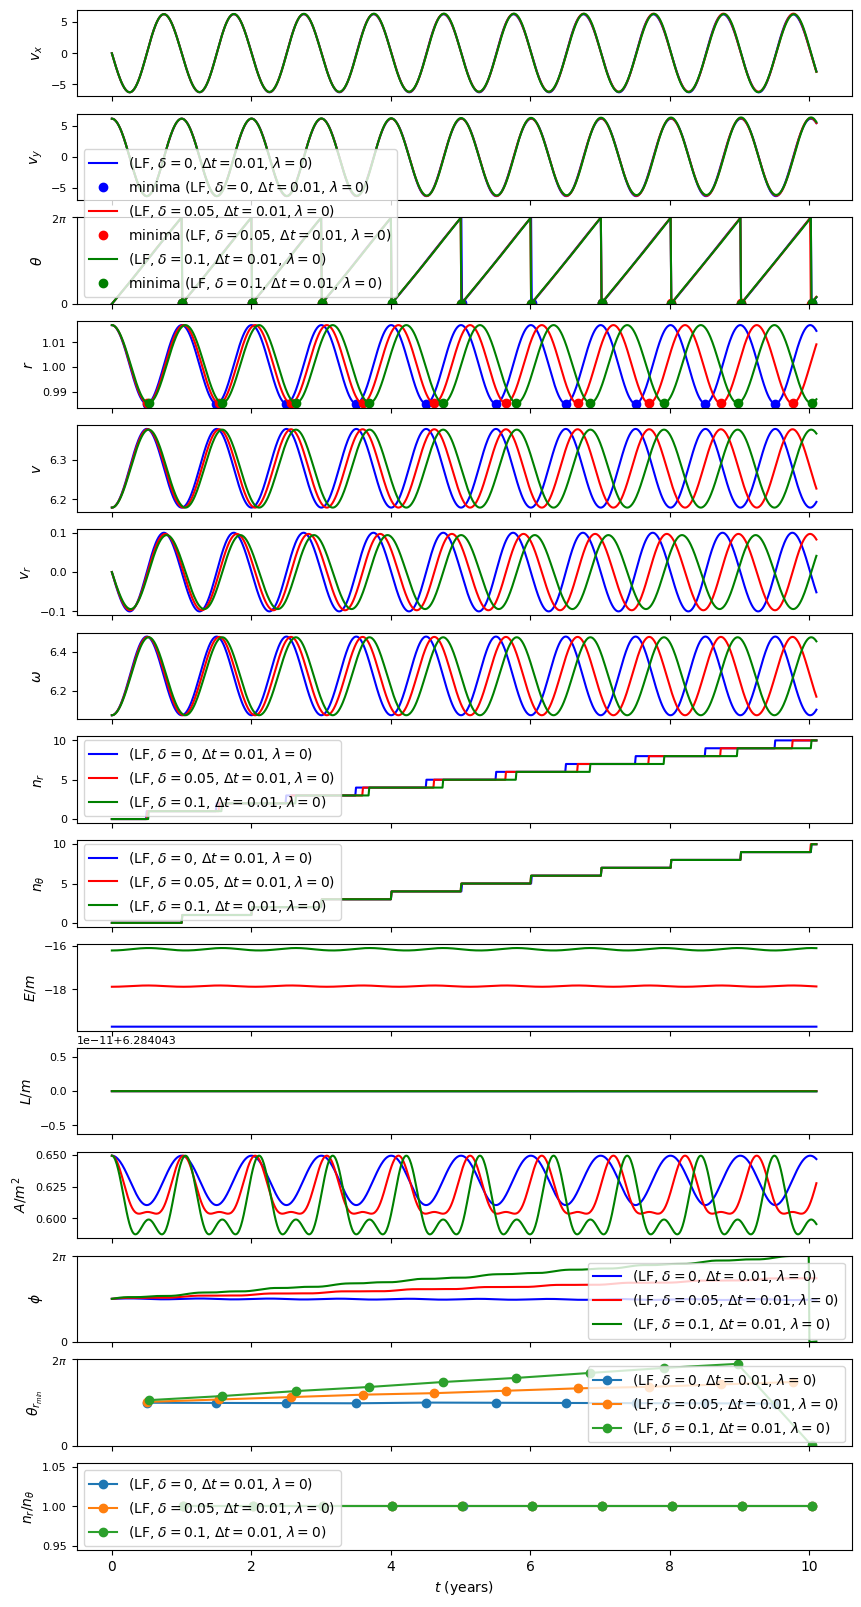

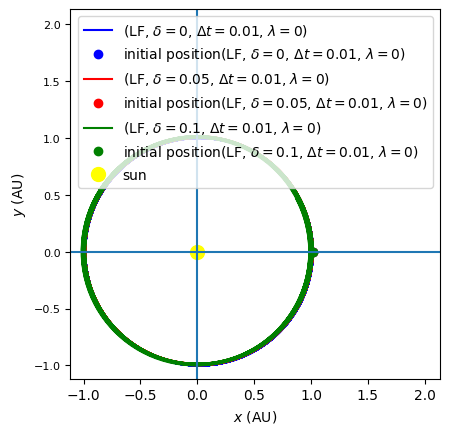

In [23]:
Orbit(vis=True,T_max=10.1,deltas=[0,0.05,0.1],methods={"LF":0.01},
    r_init=np.array([1.017, 0.0]), # AU
    v_init=np.array([0.0,6.179]) # AU/year
)
plt.show()

Defining perihelion for a single revolution as the point where the minimum distance from the sun is reached, we can now see how the angle $\theta_{r_\text{min}}$ that this point lies on (reltive to x-axis) changes with revolutions/time. 

This effect is not visible in the plot for trajectory because the trajectory isn't all that elliptic.

The same effect is also seen in the angle $\phi$ which is the angle where the Rung-Lenz vector points.

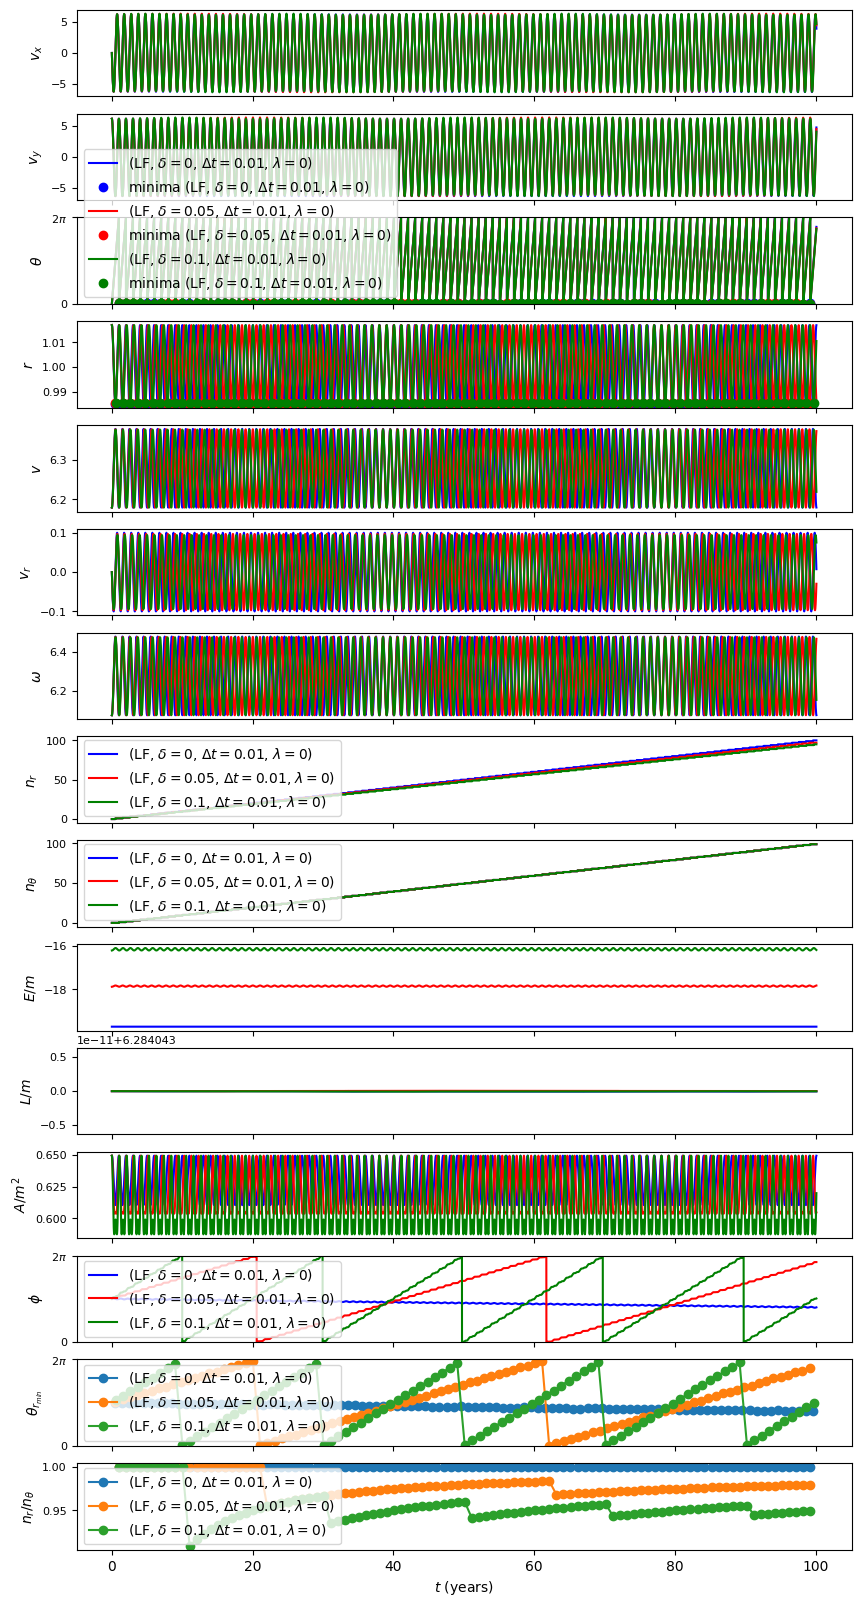

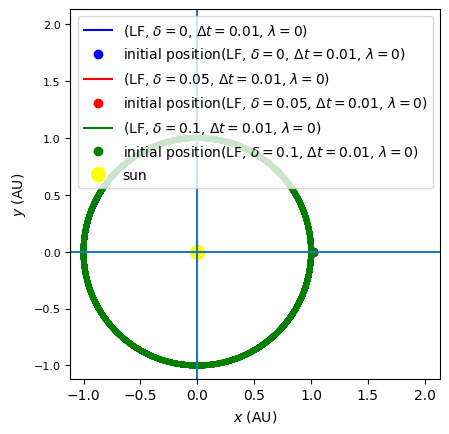

In [24]:
Orbit(vis=True,T_max=100.1,deltas=[0,0.05,0.1],methods={"LF":0.01},
    r_init=np.array([1.017, 0.0]), # AU
    v_init=np.array([0.0,6.179]) # AU/year
)
plt.show()

Take a look at the plot for $n_r/n_\theta$. You will see that the case with $\delta =0$ has no deviations, wherease others have very small (~0.05), but persistent deviation from the initial ratio of 1.

A "closed" orbit is defined as one which repeats itself over and over. Suppose during one fundamental period (of length $T_F$), we see $\Delta n_r$ new local minima for the distance $r$ and there are $\Delta n_\theta = (\Delta \theta)/(2\pi)$ revolutions (which is necessarily an integer for the position to be the same before and after the period) done by the body, and just before this period, at time $t_0$, there were $n_{r}(t_0)$ local minima in $r$ and $n_{\theta}(t_0)$ revolutions done, then it's easy to see that 

$$
n_r(t_0 + kT_F) = n_r(t_0) + k \Delta n_r \\
n_\theta(t_0 + kT_F) = n_\theta(t_0) + k \Delta n_\theta \\
\implies (\frac{n_r}{n_\theta})(t_0 + kT_F) = \frac{n_r(t_0) + k \Delta n_r}{n_\theta(t_0) + k \Delta n_\theta} 
$$

Now, since at $t=0$, our observation has just started, we have $n_r(0) = 0$. Similarly, one can _define_ $\theta(0) = 0$ by difinind the $t=0$ state as one where the body is on the x-axis (same as what we have set for the simulation). 

This gives us $n_\theta(0) = 0$. Then setting $t_0 = 0$, we simply get :

$$
(\frac{n_r}{n_\theta})(kT_F) = \frac{\Delta n_r}{\Delta n_\theta} 
$$

Even without all this, we still have :

$$
\lim_{k\to\infty}(\frac{n_r}{n_\theta})(t_0 + kT_F) = \lim_{k\to\infty}\frac{n_r(t_0) + k \Delta n_r}{n_\theta(t_0) + k \Delta n_\theta} = \frac{\Delta n_r}{\Delta n_\theta}
$$

As we saw in the plot, we also have convergence for the limit

$$
\lim_{t\to\infty}(\frac{n_r}{n_\theta})(t)
$$

This then lets us say that

$$
\lim_{t\to\infty}(\frac{n_r}{n_\theta})(t) = \lim_{k\to\infty}(\frac{n_r}{n_\theta})(t_0 + kT_F) = \frac{\Delta n_r}{\Delta n_\theta}
$$

Regardless of whether we use this limit or the $(\frac{n_r}{n_\theta})(kT_F)$ value with the correct setting ($\theta(0) = 0$), we can say that the value, which is $\frac{\Delta n_r}{\Delta n_\theta}$, is rational. This is so since $\Delta n_r$ is by definition an integer, and $\Delta n_\theta = \frac{\Delta \theta }{2\pi}$ also _needs_ to be an integer for the period $T_F$ to be a fundamental period. 

Thus we have proved that an orbit being periodic/closed implies that the ratio $n_r/n_\theta$ (with correct setting or under the $t\to\infty$ limit) is rational. 

The contrapositive is then that this ratio being irrational implies that the orbit is not closed/periodic.


Now, coming back to the results of the simulation; while we can say with certainty that the orbit with $\delta = 0$ is closed since we have $n_r/n_\theta = 1$ (a rational number), we cannot say anything about the other two cases. Since we don't know the $T_F$ for these cases (or even that these _are_ periodic; which they are not actually), we cannot compute the ratio at integer multiples of $T_F$. So instead, we must look at the limit as $t\to \infty$. While we may get a good estimate of the ratio by looking at very high $t$, we cannot know whether the result of the limit is rational or not. 

Thus, the only thing we _can_ do is evaluate the limit analytically. Effectively, we must find a way to count the number of local minima in $r(\theta)$ with the given $\delta$ and initial conditions. 

Since that is not part of this project, I will not do that.

### Part 5 : Hooke's law like force

Now, to simulate the hook's law, we will simply set $\delta := -3$

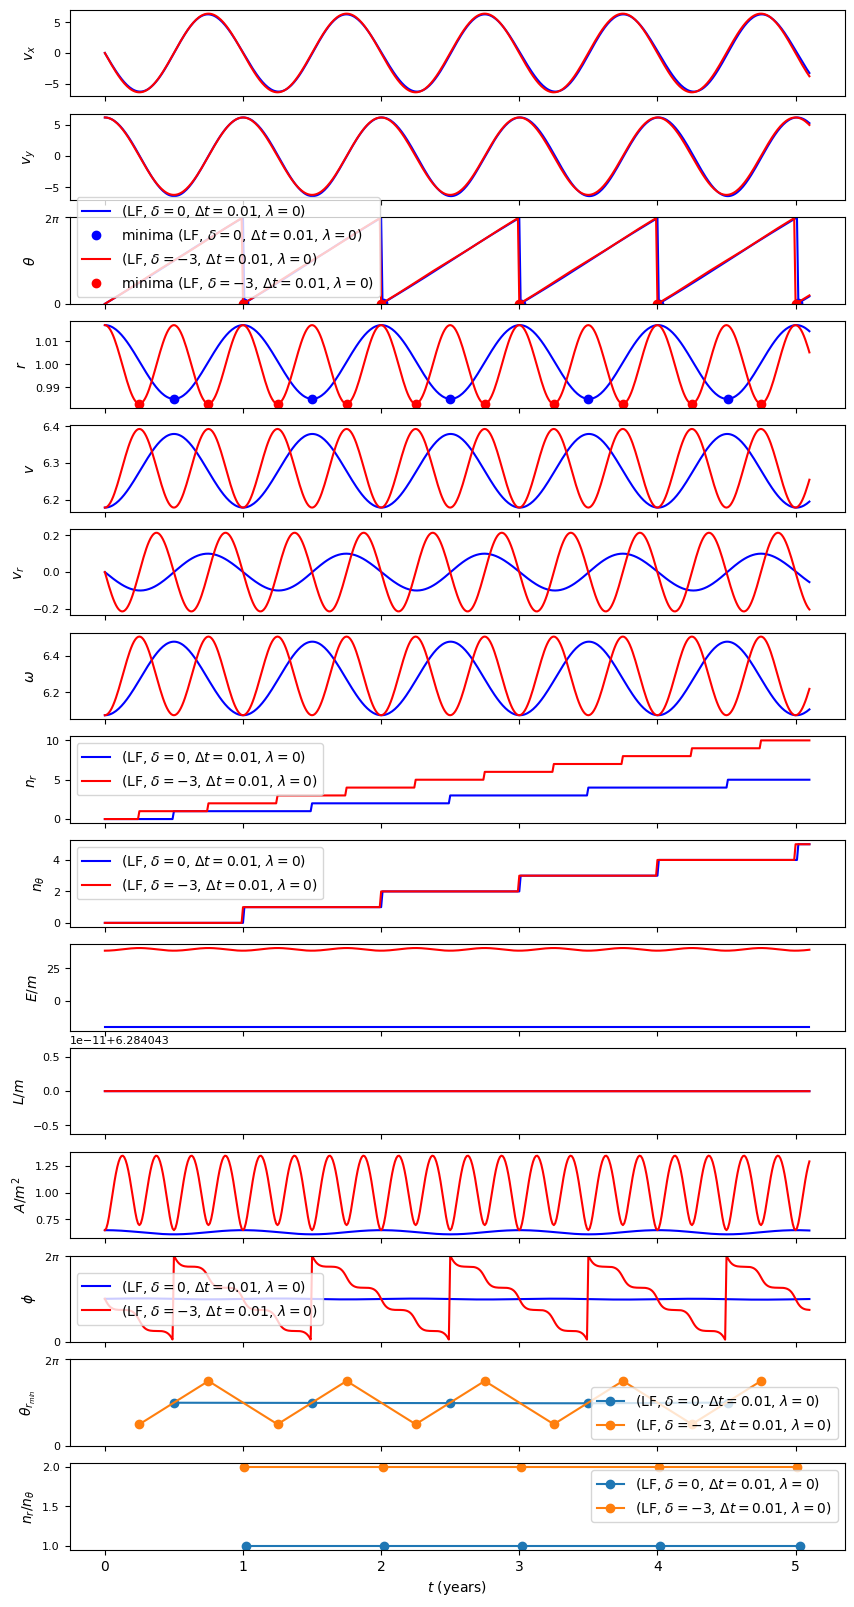

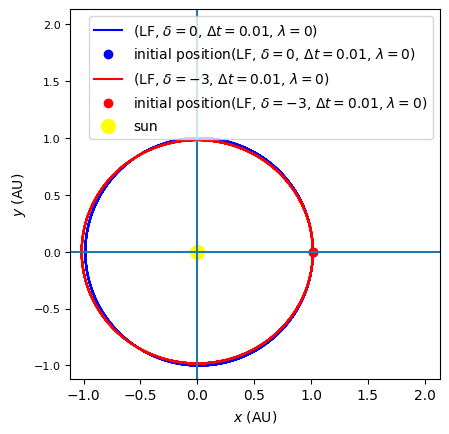

In [25]:
Orbit(vis=True,T_max=5.1,deltas=[0,-3],methods={"LF":0.01},
    r_init=np.array([1.017, 0.0]), # AU
    v_init=np.array([0.0,6.179]) # AU/year
)
plt.show()

Amazingly, the $\delta = -3$ case has its fundamental period for $\theta(t)$ match exactly with the $\delta =0$ case. 
On the other hand, the funadmental period of $r(t)$ is half that of the $\delta =0$ case. This give the consistent ratio of $n_r/n_\theta = 2$. 

Let's retry this with the initial conditions corresponding to mercury at its aphelion.

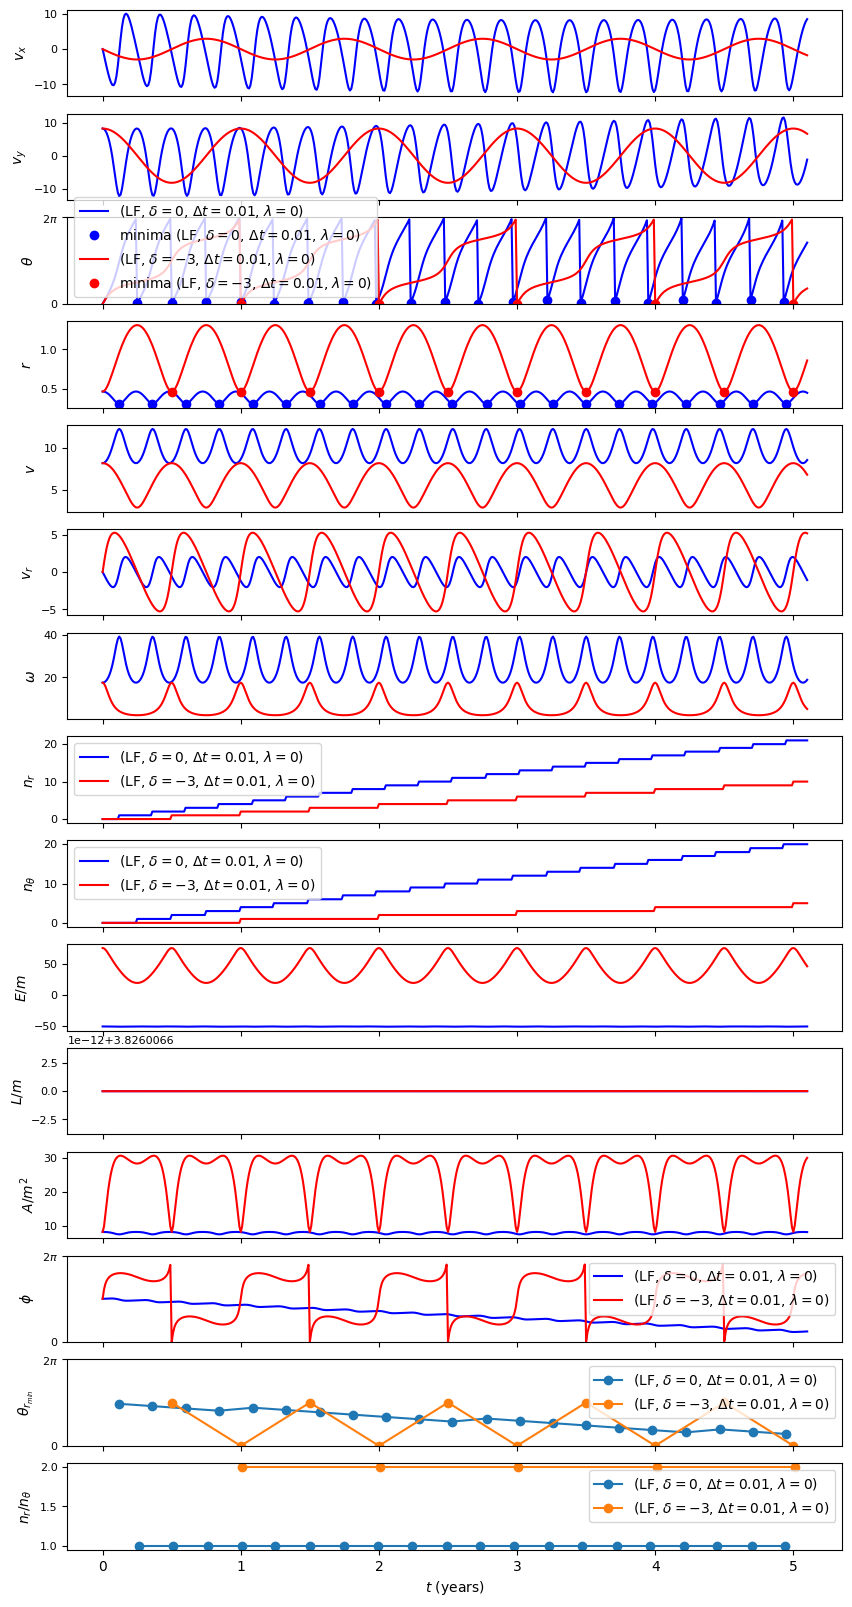

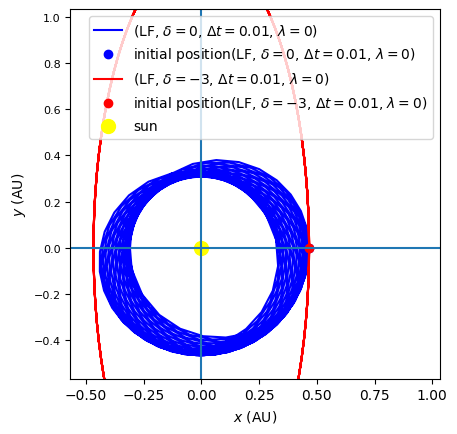

In [26]:
Orbit(vis=True,T_max=5.1,deltas=[0,-3],methods={"LF":0.01},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
plt.show()

Surprisingly, for Mercury, with a much more eliptic (real life) orbit, the $\delta =0$ case is the one that seems to appear "not closed" as the $\theta_{r_\text{min}}$ changes ever so slightly. This, I believe is due to the inadequacy of naive leapfrog integrator when dealing with high variation in velocities. To account for that, we shall use the time-transformed leap-frog integrator.

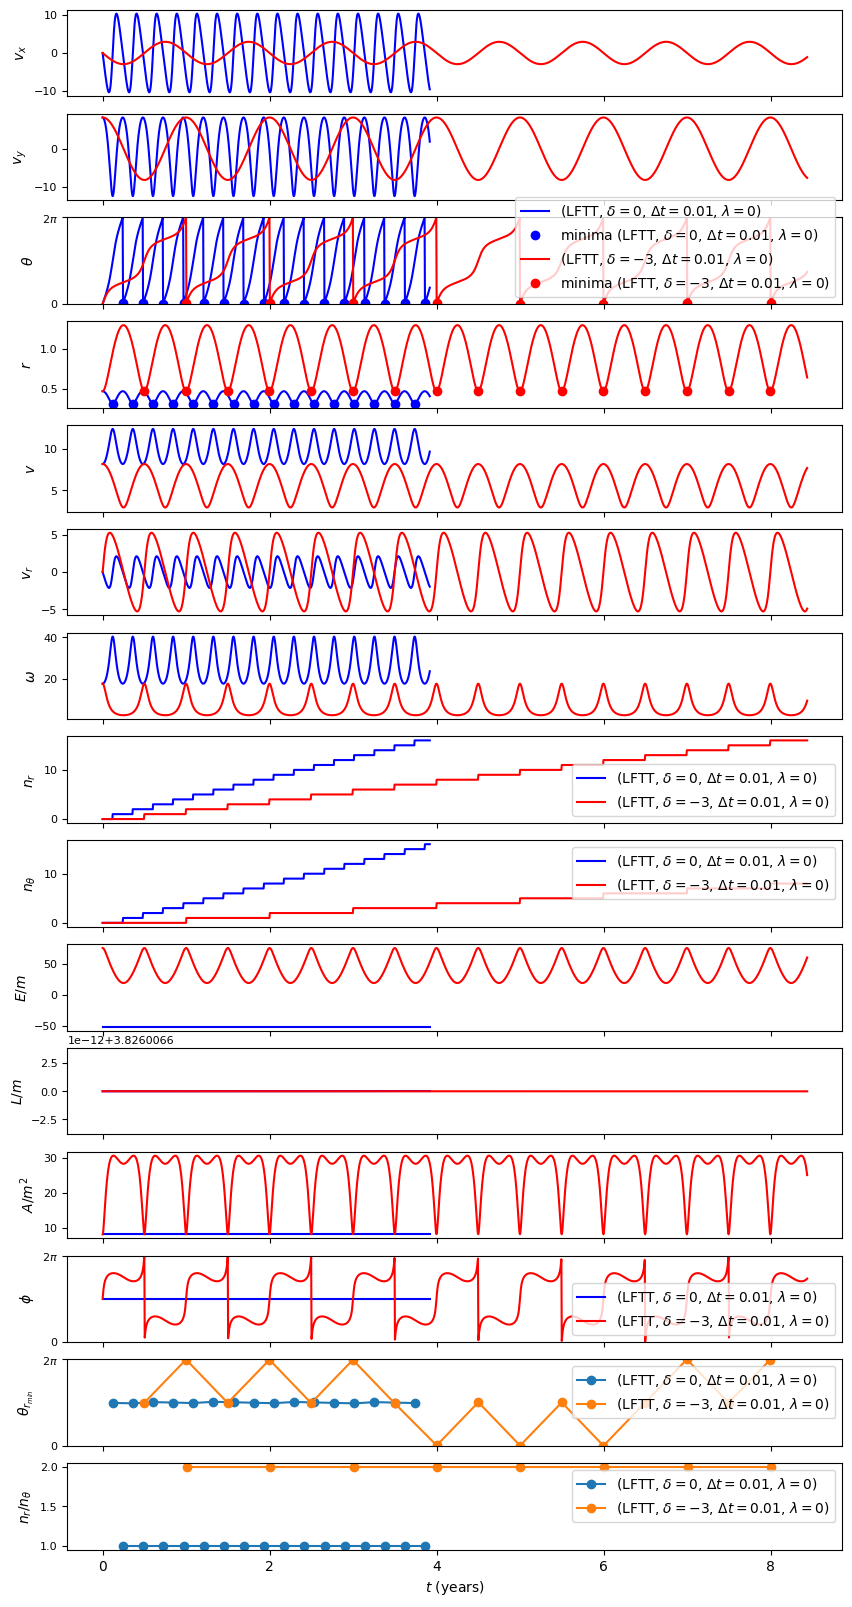

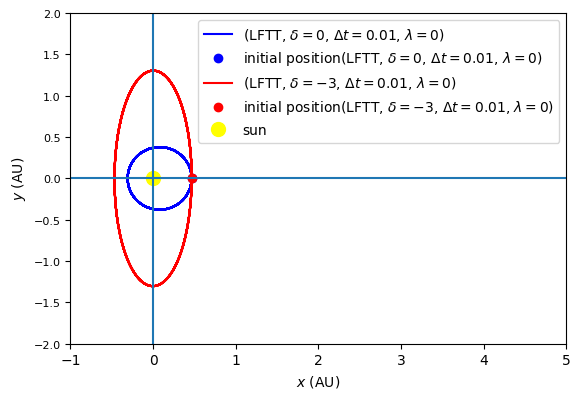

In [27]:
Orbit(vis=True,T_max=10.1,deltas=[0,-3],methods={"LFTT":0.01},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
plt.ylim(-2,2)
plt.xlim(-1,5)
plt.show()

As you can see, using the time-transformed leapfrog (LFTT) fixes the change in $\theta_{r_\text{min}}$, giving us the usual eliptic orbit for $\delta = 0$. 
Since LFTT uses a variable $s$ to parameterise the trajectory, which is different from $t$, thus the periods for which the simulation is done turn out to be different for different trajectories, even if the input intervals for $s$ are the same. 
This effect is visible in the images above as well. 

Even with the settings for Mercury, we see that $n_r/n_\theta$ stays at the value of 2 consistently. This proves that bounded orbits produced by forces following Hooke's law ($\delta = -3$) and the inverse square law ($\delta = 0$) are closed.  
The potentials corresponding to these have $r^2$ and $1/r$ power laws. This is in-line with this analytic statement (from Chapter 4 of "Computational Modeling and Visualization of Physical Systems with Python") :

> As it turns out, of all the possible forces in the universe, only $1/r$ (gravitational and
Coulombic) and $r^2$ (harmonic, i.e., Hooke's law) potentials can produce closed orbits.

The lab sheet states "$1/r$ and $r$", which is most likely a typing error.


### Extra : LFTT vs LFAS

Now, to answer the question about simply having an adaptive time step for the LF integrator, rather than using LFTT, I present the output of the "Leap-Frog-Adaptive-Step" (or LFAS for short) method, using the same parameters as LFTT. 

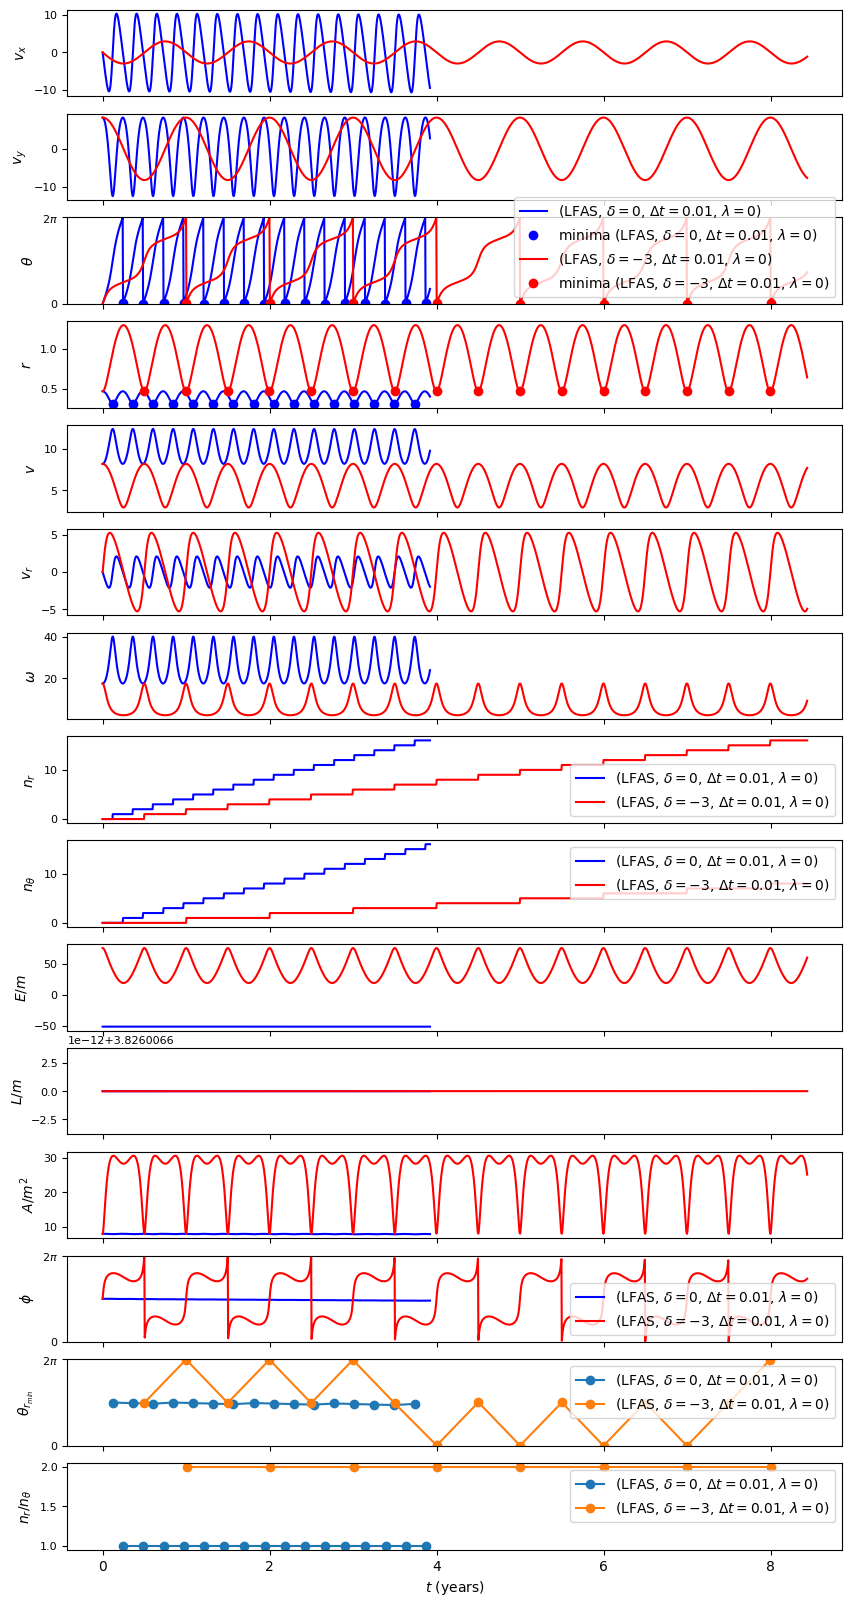

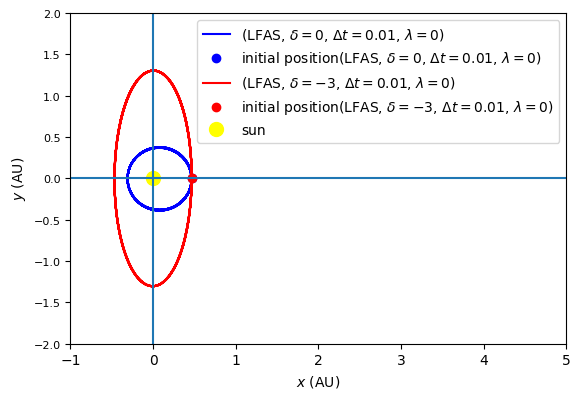

In [28]:
Orbit(vis=True,T_max=10.1,deltas=[0,-3],methods={"LFAS":0.01},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
plt.ylim(-2,2)
plt.xlim(-1,5)
plt.show()

As you can see, the deviation of $\theta_{r_\text{min}}$ that we encountered for the normal leapfrog integrator isn't there. Thus, both methods are similar in output. 

## Mini-Project 2 : Precession of Mercury

### Parts A,B,C

precession using angle at perihelion: 
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0.005$)  :  1.0476  radians/year
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0.003$)  :  0.6263  radians/year
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0.001$)  :  0.23  radians/year
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0$)  :  0.0083  radians/year
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=1.1e-08$)  :  0.0083  radians/year
precession using angle at perihelion with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0.005$)  :  0.2509467879322647 radians/revolution | R^2 :  0.9979097688779689
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0.003$)  :  0.14927165697169045 radians/revolution | R^2 :  0.9999999999999257
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0.001$)  :  0.05211221276734742 radians/revolution | R^2 :  0.958057390598054
(LFTT, $\delta={0}$, $\Delta t=0.005$, $\lambda=0$)  :  0.0019931007486403344 radians/revolution | R^2 :  0.03311334551070999


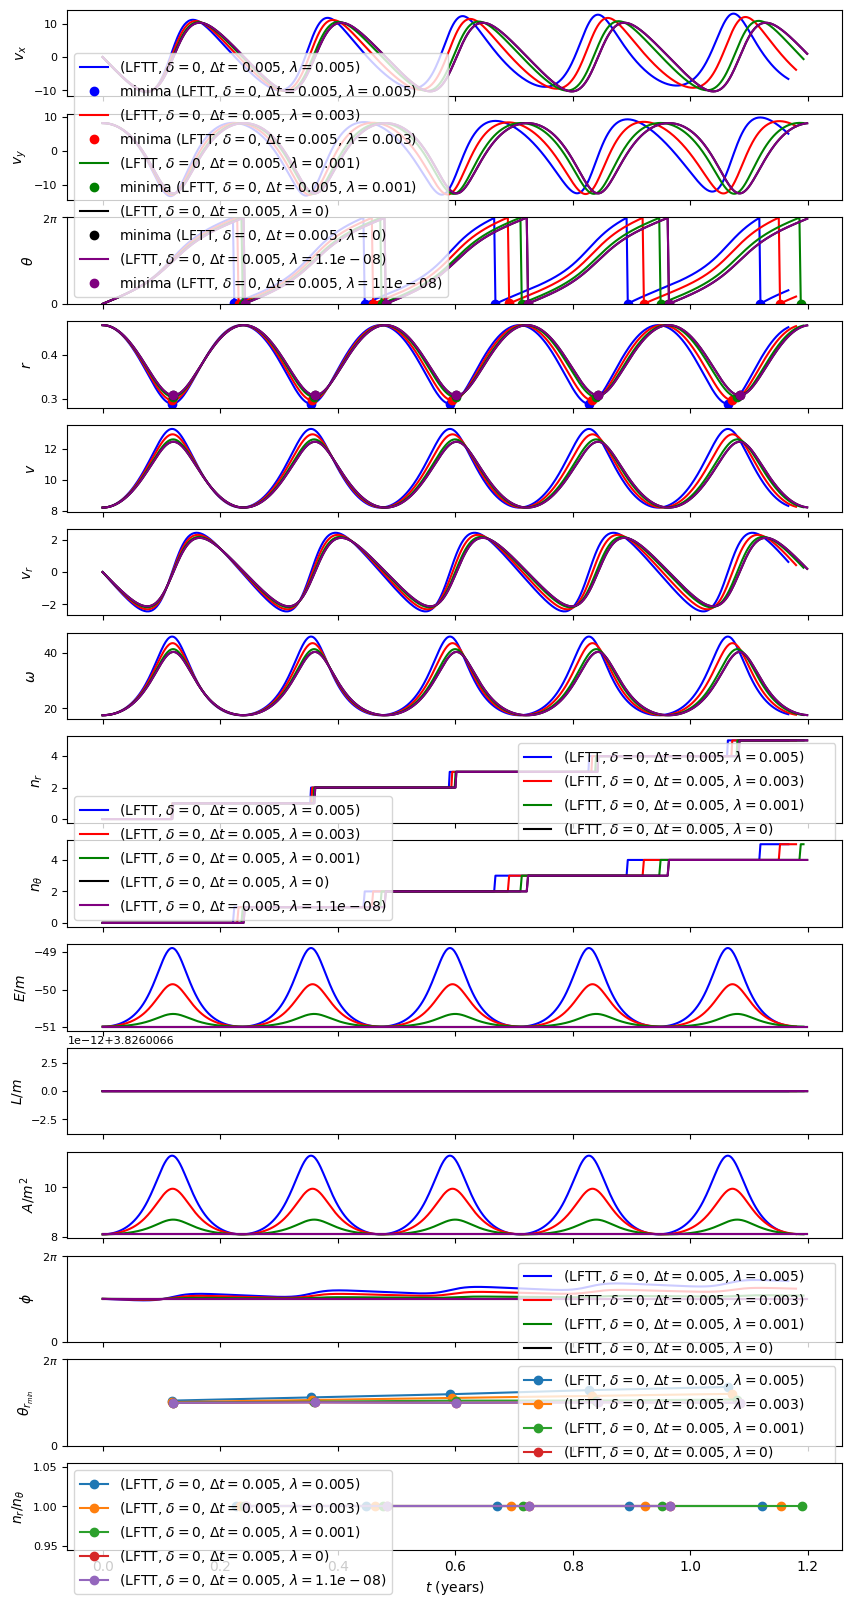

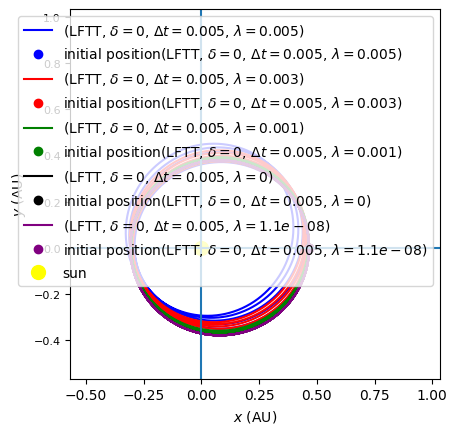

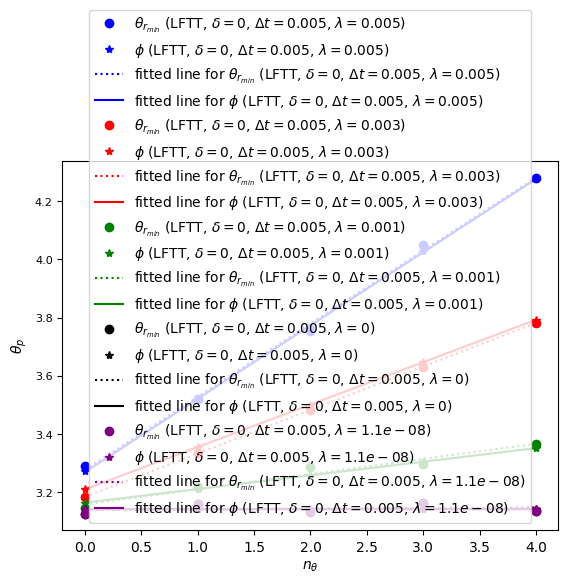

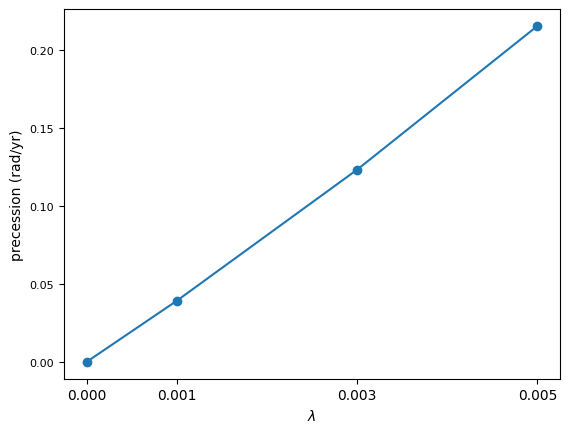

In [13]:
output = Orbit(
    vis=True,vis_prec=True,T_max=3.1,deltas=[0],lambs=[0.005,0.003,0.001,0,1.1e-8],methods={"LFTT":0.005},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
precession_theta_r_min = output[0]
precession_theta_r_min_regression = output[1]
precession_theta_r_min_regression_R2 = output[2]
precession_phi = output[3]
precession_phi_regression = output[4]
precession_phi_regression_R2 = output[5]
print("precession using angle at perihelion: ")
for x,y in precession_theta_r_min.items(): print(x," : ",round(y,4), " radians/year")
print("precession using angle at perihelion with regression: ")
for cond in precession_theta_r_min_regression: 
    print(cond," : ",
    precession_theta_r_min_regression[cond],
    "radians/revolution | R^2 : ",
    precession_theta_r_min_regression_R2[cond])
print("precession using Rung-Lenz vector direction: ")
for x,y in precession_phi.items(): print(x," : ",round(y,4), " radians/year")
print("precession using Rung-Lenz vector direction with regression: ")
for cond in precession_phi_regression: 
    print(cond," : ",
    precession_phi_regression[cond],
    "radians/revolution | R^2 : ",
    precession_phi_regression_R2[cond])
plt.figure()
plt.plot([0.005,0.003,0.001,0],list(precession_phi_regression.values())[:-2] + [0],'-o')
plt.xlabel(r"$\lambda$")
plt.ylabel(r"precession (rad/yr)")
plt.xticks([0.005,0.003,0.001,0])
plt.show()

As you can see from the plot of the trajectory, the $\lambda=0.01$ case does not appear to be closed. Moreover, we see that the angles $\phi$ and $\theta_{r_\text{min}}$, both of which are estimates for the angle $\theta_p$ that gives the position of the periheliion, increase linearly with $n_\theta$. At $\lambda=0.01$, the goodness of fit ($R^2$) for linear regression of $\phi$ and $\theta_{r_\text{min}}$ on $n_\theta$ are around 0.9981 and 0.9997 respectively. This is clear evidence of the linear relationship. 

Also, for $\lambda = 1.1\times10^{-8}$, we see $R^2$ values of 0.0227 and 0.9994 when using $\theta_{r_\text{min}}$ and $\phi$ for data-points respectively.

The low goodness of fit for $\theta_{r_\text{min}}$ might be because the time-frame is too small.
Moving to slightly more than a century, we may see a higher $R^2$.

But first, I will do it for  ~10 years.

precession using angle at perihelion: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  -136.5878  arc-seconds/year
precession using angle at perihelion with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  -9.577008486176128 arc-seconds/revolution | R^2 :  0.0018492469107205256
precession using Rung-Lenz vector direction: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  0.4071  arc-seconds/year
precession using Rung-Lenz vector direction with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  0.10367929128421743 arc-seconds/revolution | R^2 :  0.9999985258208333


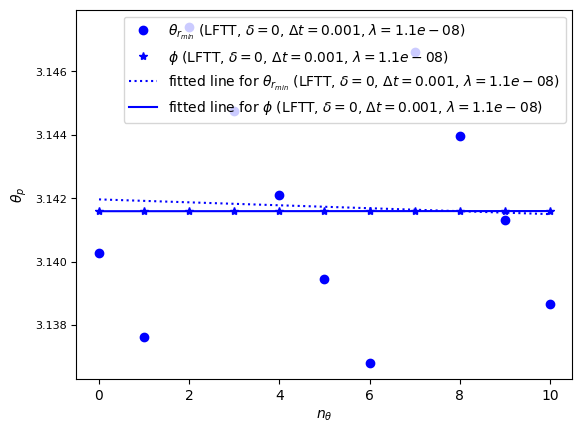

In [30]:
output = Orbit(
    vis=False,vis_prec=True,T_max=7.1,deltas=[0],lambs=[1.1e-8],methods={"LFTT":0.001},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
precession_theta_r_min = output[0]
precession_theta_r_min_regression = output[1]
precession_theta_r_min_regression_R2 = output[2]
precession_phi = output[3]
precession_phi_regression = output[4]
precession_phi_regression_R2 = output[5]
cf = 3600*180/np.pi
print("precession using angle at perihelion: ")
for x,y in precession_theta_r_min.items(): print(x," : ",round(cf*y,4), " arc-seconds/year")
print("precession using angle at perihelion with regression: ")
for cond in precession_theta_r_min_regression: 
    print(cond," : ",
    cf*precession_theta_r_min_regression[cond],
    "arc-seconds/revolution | R^2 : ",
    precession_theta_r_min_regression_R2[cond])
print("precession using Rung-Lenz vector direction: ")
for x,y in precession_phi.items(): print(x," : ",round(cf*y,4), " arc-seconds/year")
print("precession using Rung-Lenz vector direction with regression: ")
for cond in precession_phi_regression: 
    print(cond," : ",
    cf*precession_phi_regression[cond],
    "arc-seconds/revolution | R^2 : ",
    precession_phi_regression_R2[cond])
plt.show()

As you can see, there is a lot of noise in the estime $\theta_{r_\text{min}}$ for $\theta_p$. Compared to that, $\phi$ (Rung-Lenz vector direction) performs much better. 
The period of revolution for Mercury is around 88 days, or 0.241 years, the quantity from linear regression translates to around 0.43 arc-seconds per year. This is also what one expects to find.
In comparison, the $\theta_{r_{max}}$ estimate gives really poor results.

In [31]:
0.10367929128421743 / 0.241

0.4302045281502798

Now, we can do the same computation, but for more than a 1000 years. This should improve the accuracy.

precession using angle at perihelion: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  136.1009  arc-seconds/century
precession using angle at perihelion with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  42.139729278695455 arc-seconds/century | R^2 :  0.0040305284999546664
precession using Rung-Lenz vector direction: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  43.0201  arc-seconds/century
precession using Rung-Lenz vector direction with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  43.02272472398365 arc-seconds/century | R^2 :  0.9999999999241171


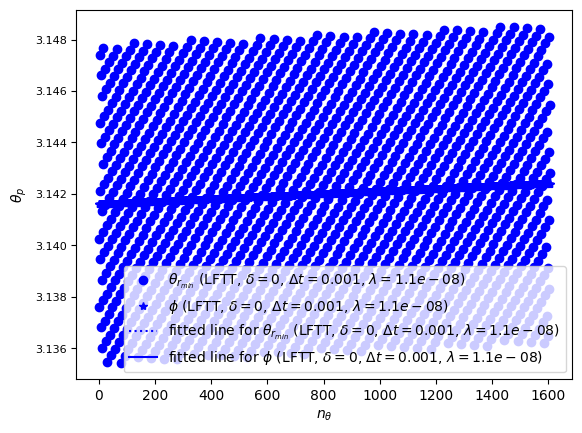

In [32]:
output = Orbit(
    vis=False,vis_prec=True,T_max=1000.1,deltas=[0],lambs=[1.1e-8],methods={"LFTT":0.001},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
precession_theta_r_min = output[0]
precession_theta_r_min_regression = output[1]
precession_theta_r_min_regression_R2 = output[2]
precession_phi = output[3]
precession_phi_regression = output[4]
precession_phi_regression_R2 = output[5]
cf = 100*3600*180/np.pi
print("precession using angle at perihelion: ")
for x,y in precession_theta_r_min.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using angle at perihelion with regression: ")
for cond in precession_theta_r_min_regression: 
    print(cond," : ",
    cf*precession_theta_r_min_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_theta_r_min_regression_R2[cond])
print("precession using Rung-Lenz vector direction: ")
for x,y in precession_phi.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using Rung-Lenz vector direction with regression: ")
for cond in precession_phi_regression: 
    print(cond," : ",
    cf*precession_phi_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_phi_regression_R2[cond])
plt.show()

As you can see, now even the $\theta_{r_{max}}$ metric is giving output that is consistent with the known value of 43'' per century.

precession using angle at perihelion: 
(LFTT, $\delta={0}$, $\Delta t=1e-05$, $\lambda=1.1e-08$)  :  493.3639  arc-seconds/century
precession using angle at perihelion with regression: 
(LFTT, $\delta={0}$, $\Delta t=1e-05$, $\lambda=1.1e-08$)  :  117.3805755582181 arc-seconds/century | R^2 :  0.033940286062663194
precession using Rung-Lenz vector direction: 
(LFTT, $\delta={0}$, $\Delta t=1e-05$, $\lambda=1.1e-08$)  :  40.9899  arc-seconds/century
precession using Rung-Lenz vector direction with regression: 
(LFTT, $\delta={0}$, $\Delta t=1e-05$, $\lambda=1.1e-08$)  :  43.02469114242521 arc-seconds/century | R^2 :  0.9999999999319742


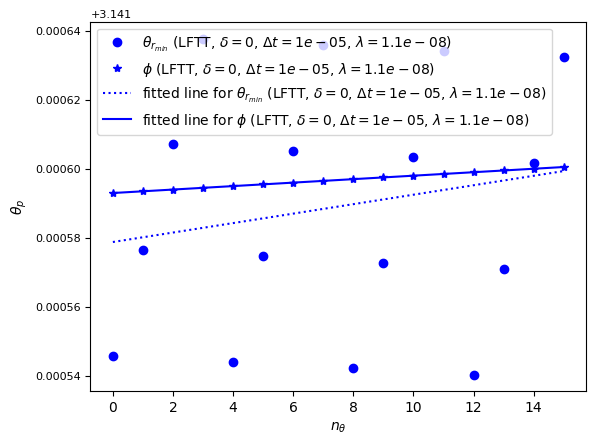

In [33]:
output = Orbit(
    vis=False,vis_prec=True,T_max=10.1,deltas=[0],lambs=[1.1e-8],methods={"LFTT":0.00001},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
precession_theta_r_min = output[0]
precession_theta_r_min_regression = output[1]
precession_theta_r_min_regression_R2 = output[2]
precession_phi = output[3]
precession_phi_regression = output[4]
precession_phi_regression_R2 = output[5]
cf = 100*3600*180/np.pi
print("precession using angle at perihelion: ")
for x,y in precession_theta_r_min.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using angle at perihelion with regression: ")
for cond in precession_theta_r_min_regression: 
    print(cond," : ",
    cf*precession_theta_r_min_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_theta_r_min_regression_R2[cond])
print("precession using Rung-Lenz vector direction: ")
for x,y in precession_phi.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using Rung-Lenz vector direction with regression: ")
for cond in precession_phi_regression: 
    print(cond," : ",
    cf*precession_phi_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_phi_regression_R2[cond])
plt.show()

Decreasing $\Delta t$ significantly reduces the deviations in $\theta_{r_{max}}$, making the estimate based on that more accurate. But this effect is not as good as the effect gained on increasing the timespan, when normalised by the computational cost increase. 

Since part A asks us to run the LFTT method for about 100 years and see if $E,L$ are conserved as well as whether the orbit is closed, I will show all the plots.

precession using angle at perihelion: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  -2008.9556  arc-seconds/century
precession using angle at perihelion with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  36.33579464460356 arc-seconds/century | R^2 :  1.9418359850420508e-05
precession using Rung-Lenz vector direction: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  43.3243  arc-seconds/century
precession using Rung-Lenz vector direction with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.001$, $\lambda=1.1e-08$)  :  43.022721397043426 arc-seconds/century | R^2 :  0.9999999882422095


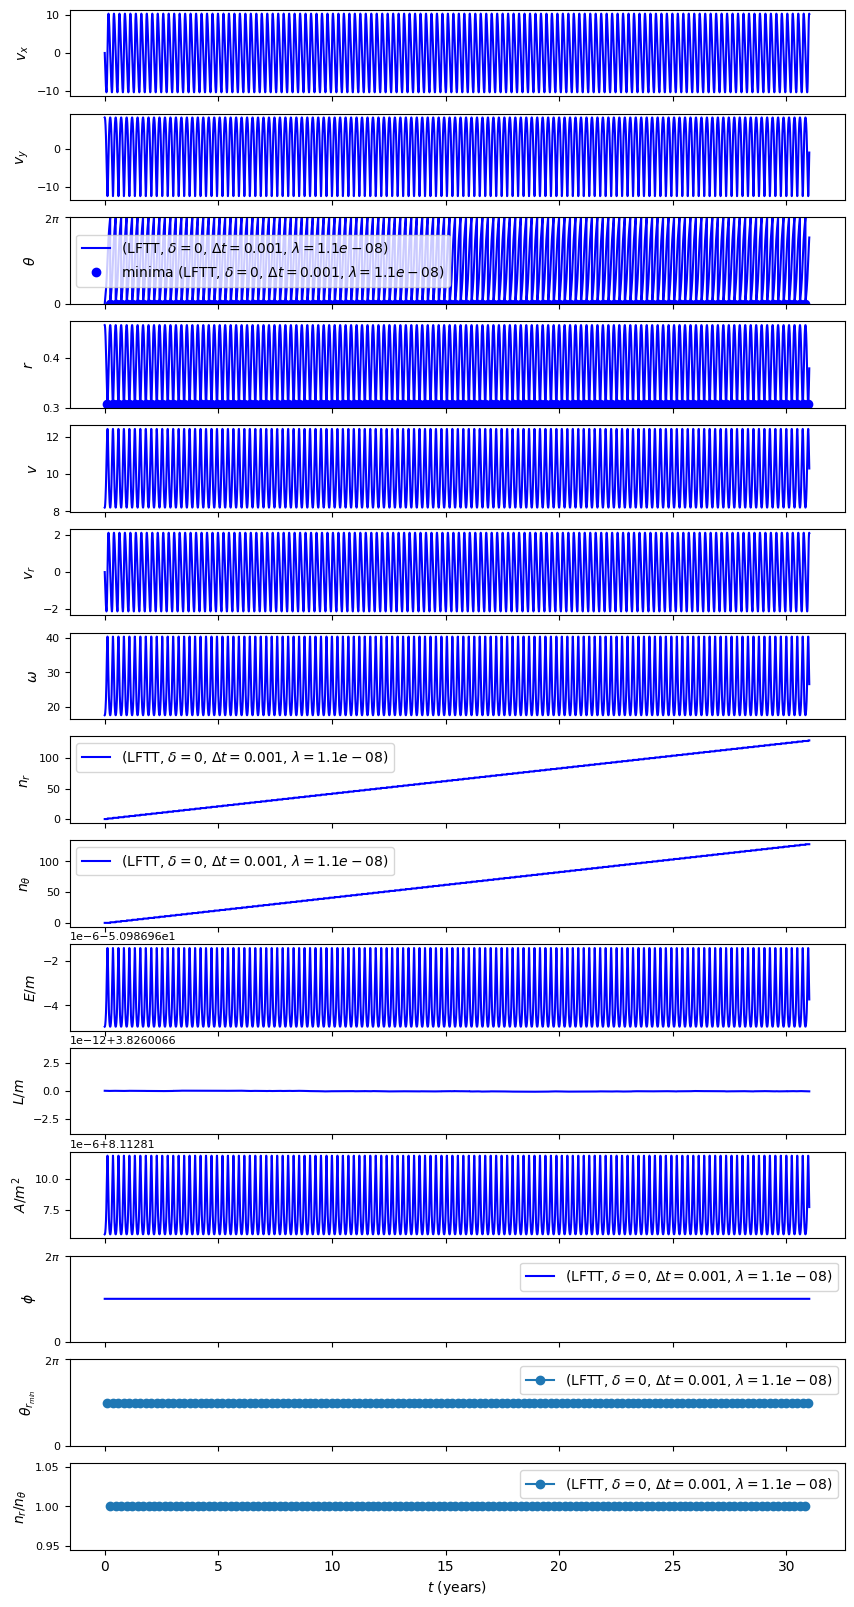

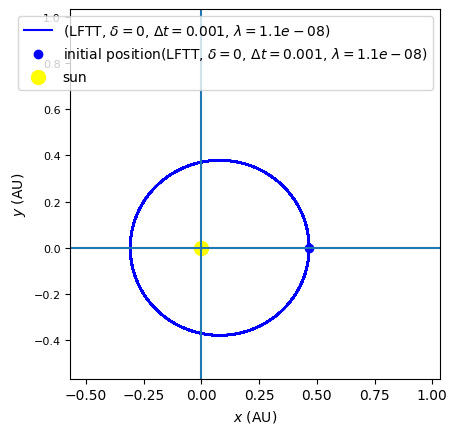

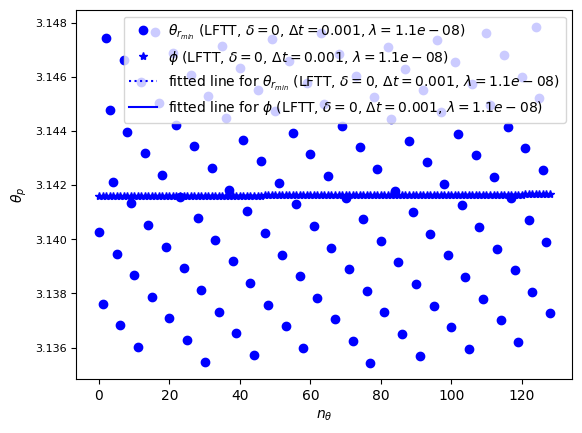

In [34]:
output = Orbit(
    vis=True,vis_prec=True,T_max=80.1,deltas=[0],lambs=[1.1e-8],methods={"LFTT":0.001},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
precession_theta_r_min = output[0]
precession_theta_r_min_regression = output[1]
precession_theta_r_min_regression_R2 = output[2]
precession_phi = output[3]
precession_phi_regression = output[4]
precession_phi_regression_R2 = output[5]
cf = 100*3600*180/np.pi
print("precession using angle at perihelion: ")
for x,y in precession_theta_r_min.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using angle at perihelion with regression: ")
for cond in precession_theta_r_min_regression: 
    print(cond," : ",
    cf*precession_theta_r_min_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_theta_r_min_regression_R2[cond])
print("precession using Rung-Lenz vector direction: ")
for x,y in precession_phi.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using Rung-Lenz vector direction with regression: ")
for cond in precession_phi_regression: 
    print(cond," : ",
    cf*precession_phi_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_phi_regression_R2[cond])
plt.show()

precession using angle at perihelion: 
(LFTT, $\delta={0}$, $\Delta t=0.01$, $\lambda=1.1e-08$)  :  -1641.3769  arc-seconds/century
precession using angle at perihelion with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.01$, $\lambda=1.1e-08$)  :  -1195.8516066100246 arc-seconds/century | R^2 :  0.00021150179616480358
precession using Rung-Lenz vector direction: 
(LFTT, $\delta={0}$, $\Delta t=0.01$, $\lambda=1.1e-08$)  :  43.0757  arc-seconds/century
precession using Rung-Lenz vector direction with regression: 
(LFTT, $\delta={0}$, $\Delta t=0.01$, $\lambda=1.1e-08$)  :  42.83216405272399 arc-seconds/century | R^2 :  0.9999988286962556


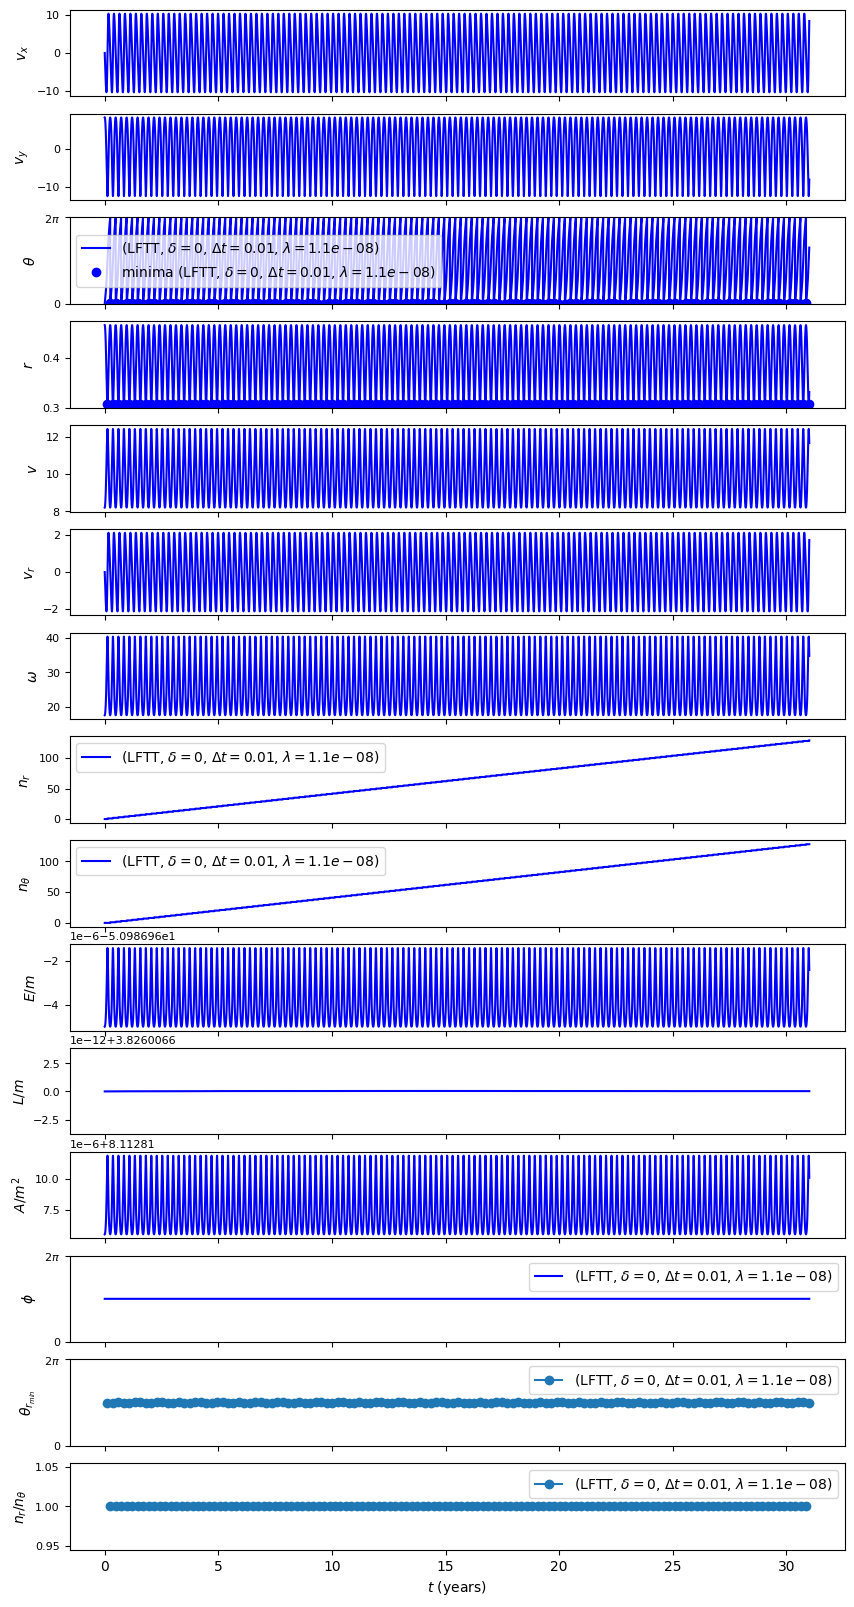

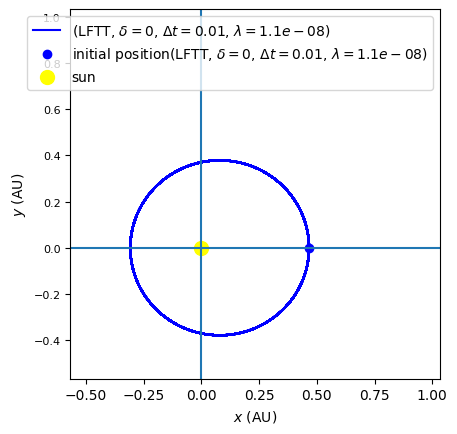

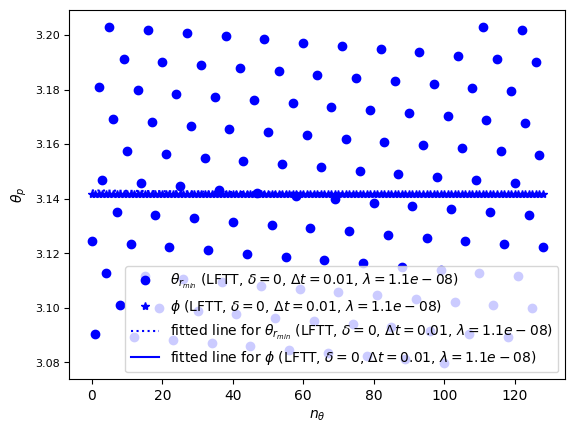

In [35]:
output = Orbit(
    vis=True,vis_prec=True,T_max=80.1,deltas=[0],lambs=[1.1e-8],methods={"LFTT":0.01},
    r_init=np.array([0.4667, 0.0]), # AU
    v_init=np.array([0.0, 8.198]) # AU/year
)
precession_theta_r_min = output[0]
precession_theta_r_min_regression = output[1]
precession_theta_r_min_regression_R2 = output[2]
precession_phi = output[3]
precession_phi_regression = output[4]
precession_phi_regression_R2 = output[5]
cf = 100*3600*180/np.pi
print("precession using angle at perihelion: ")
for x,y in precession_theta_r_min.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using angle at perihelion with regression: ")
for cond in precession_theta_r_min_regression: 
    print(cond," : ",
    cf*precession_theta_r_min_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_theta_r_min_regression_R2[cond])
print("precession using Rung-Lenz vector direction: ")
for x,y in precession_phi.items(): print(x," : ",round(cf*y,4), " arc-seconds/century")
print("precession using Rung-Lenz vector direction with regression: ")
for cond in precession_phi_regression: 
    print(cond," : ",
    cf*precession_phi_regression[cond]/0.241,
    "arc-seconds/century | R^2 : ",
    precession_phi_regression_R2[cond])
plt.show()

As you can see, the value of $E/m$ is consistently around $-50.987$ when $\Delta t = 0.001$ , with the variation being on the scale of $10^{-6}$ (as displayed in the plot). Similarly, $L/m$ and $A/m^2$ have variations on the scale of $10^{-12}$ and $10^{-6}$ which are miniscule compared to their average values.  

### Part D : Short Comparison

As is evident from all the plots I have made, direct perihelion tracking is not as accurate as using the Rung-Lenz vector when $\lambda$ is very small (and thus, for small precession rates). 

Also, both the methods are equally sensitive to the time-step, whith the error scaling linearly. Take a look at this table for metrics signifying the error for $\Delta t = 0.01$ and $\Delta t = 0.001$ for a period of 30 (physical years).

| $\Delta t$ | maximum absolute deviation for $\theta_{r_\text{min}}$ | $(1-R^2)$ for $\phi$ |
| ---------- | ------------------------------------------------------ | ------------------ |
| 0.01 | 0.06 | 0.0000012 |
| 0.001 | 0.006 | 0.000000012 |
                  
Since $1-R^2 = \text{SSE}/\text{SST}$, to compare it with the absolute deviation, we must take a square root. 
Then, we can see that both the maximum absolute deviation in $\theta_{r_\text{min}}$ and the $\sqrt{1-R^2}$ value for $\phi$ increase by a factor of 10 when going from $\Delta t = 0.01$ to $\Delta t = 0.1$. 

Note: since the linear fit with $\phi$ is _really_ well, with extremely low $R^2$, we can say that $\text{SST}\approx \text{SSR}$ is effectively the standard deviation of the _actual_ line (the one observed in real life) and is thus constant w.r.t $\Delta t$ in the regime we are dealing with. Thus, when $\sqrt{1-R^2}$ changes by a factor of 10, it's actualy the RMSE of the prediction that has changed by a factor of 10. The maximum absolute deviation will also change by the same factor. 

### Part E : Time scales and detectability

1. With the orbital period of $T_\text{orb}\approx 0.241 \text{ yr}$ and known GR precision rate $\Theta_p =\frac{d\theta_p}{dt}$ of 43 arc-seconds per century, or $2.08 \times 10^{-6} \text{ rad}/\text{yr}$, 
    * The precision per orbit is $\Theta_p T_\text{orb} \approx 5\times 10^{-7} \text{rad}$ or around 0.104 arc-seconds.
    * The number of orbits required for just slightly more than a full $2\pi$ precession is $\frac{2\pi \text{ rad}}{\Theta_p T_\text{orb}} \approx 12506032$.
    * The amount of _time_ required for full $2\pi$ precession is $\frac{2\pi \text{ rad}}{\Theta_p} \approx 3013953.5 \text{ yr} \approx 30139.5 \text{ century} $

In [36]:
Theta_p_arcsecs = 43
Theta_p_rad = 43*(1/3600)*(np.pi/180)/100
T_orb = 0.241
(Theta_p_arcsecs/100)*T_orb, Theta_p_rad*T_orb

(0.10363, 5.024124177338121e-07)

In [37]:
2*np.pi / (Theta_p_rad*T_orb)

12506031.072083376

In [38]:
2*np.pi / Theta_p_rad

3013953.488372093

2. Suppose my scheme can resolve angulare changes upto a precision (maximum absolute deviation) $p$, then the time required for the (actual) precision to reach $10p$ (a sufficiently large precession) is $\frac{10p}{\Theta_p}$ . For a $p=10^{-5}$, this is about 48 years. 

With a $\Delta t = 0.001$, the precision reached using the $\theta_{r_\text{min}}$ is $p =0.006$. Thus on simulating for a time of $T = 100 \text{ yr}$ , which gives us an expected precession of $T \Theta_p \approx 2\times 10^{-6} \text{ rad}/\text{yr}$, the precision $p$ is terrible, as $p \gg T\Theta_p$ .
To actually get an accurate value, we should run the simulation for at least $p/\Theta_p \approx 29 \text{ century}$ , which will give us a mean absolute error of $p$, and thus a much better fit for the linear regression.

In [39]:
p = 1e-5
(10*p / Theta_p_rad)

47.968559592347994

3. The angular change $\Delta \theta (t)$ for a given step $(t, t + \Delta t)$ is approximately $\omega (t) \Delta t$. Now, since we are using a time-transformed leap-frog, we actually have $\omega(t)\Delta s/\Omega(r) = \omega r\Delta s $ . This $\Delta s$ is what I have been refering to as "$\Delta t$" till now. The step $\Delta s$ we used was $0.001 \text{ yr}/\text{AU}$. 

   At the aphelion, we can very roughly estimate $r$ and $\omega$ to be $0.5 \text{ AU}$ and $\text{20} \text{ rad}/\text{yr}$, giving us a $\Delta \theta$ of $0.01 \text{ rad}$ at the aphelion. 
   At the perihelion, we have $r \approx 0.3 \text{ AU}$ and $\omega \approx 40 \text{ rad}/\text{yr}$. This gives us $\Delta \theta \approx 0.012 \text{ rad}$. Both these $\Delta \theta$ are much larger than the $5 \times 10^{-7} \text{ rad}$ of precession that we expect on a single revolution. Since $\Delta \theta$ increases monotonically as we move from the aphelion to the perihelion, all $\Delta \theta (t)$ lie in the same range. 
   
   Thus, direct visual inspection of a single orbit will not reveal any precession. 

4. The assumptions that allow us to compress the centuries of real-life dynamics into a short (2 minutes at max) numerical run are that of appropriate time and physical scales (1 year, or $\tau = T_\text{orb} \approx 0.241 \text{ yr}$ to be precise, and 1 AU or $a_\text{mercury} \approx 0.4 \text{AU}$ to be precise), and the step size $\Delta t$ being much smaller than the time-scale ($\Delta t \le r_\text{ap}\Delta s \approx 0.0005 \text{ yr} \ll T_\text{orb} = 0.241 \text{yr}$).  The last requirement is for the error $p$ in the year to year (or on a scale of $\tau$) estimate of the quanity we are trying to estimate (perihelion position at the end of simulation) be much smaller than the quantity itself (at least $10p$ at the end of the simulation).
The same requirements would need to be satisfied to estimate precession for a single revolution. In particular, the second requirement, namely the year-to-year error $p$ being much smaller than the precession is the most crucial and the most costly to meet. It is costly because now the total precession is much smaller, as compared to a century. So, the goal is to reduce $p$ as much as possible, which can only be done by reducing $\Delta t$. 

### Extra : Rung Lenz vector is a preserved quantity, and connection with $so(4)$

We already know that for any scalar quantity $f(\vec q, \vec p)$, we have :

$$
\frac{d}{dt}f = \{f,H\}
$$

This is Liouville's theorem. This then carries over easily to statistical mechaics, but for the probability density $\rho$.
There's an analogous theorem in Quantum Statistical Mechanics for density matrices ($\hat \rho = \ket{\psi}\bra{\psi}$) which is very useful when you have mixed states. The analogous theorem I talked about is :

$$
i\hbar\frac{\partial}{\partial t}\hat\rho = [\hat H,\hat \rho] = \hat H \hat \rho - \hat \rho \hat H
$$

It seems all of physics is littered with commutator, for the uncertainity principle to classical mechanics. 

Now, as with all quantities, the Rung-Lenz vector's components also follows Liouville's theorem, giving us:

$$
\frac{d}{dt} \vec A = \{\vec A,H\}
$$

Using the definition of $\vec A$, we can write :

$$
\{\vec A,H\} = \{\vec p \times \vec L , H\} - GMm\{\hat r, H\}
$$

But then using product rule for terms of form $p_iL_j$, we can easily get :

$$
\{\vec p \times \vec L , H\} = \{\vec p, H\} \times \vec L + \vec p \times \{\vec L, H\}
\\ = (\frac{d}{dt}\vec p)\times \vec L + \vec p \times (\frac{d}{dt}\vec L)
$$

Now, since the force is radial, we have $\frac{d}{dt}\vec L = 0$. As for $\frac{d}{dt}\vec p$ , that's just the force , namely $\vec F = - \frac{GMm}{r^2}\hat r$ . So, this leaves us with :

$$
\{\vec p \times \vec L , H\} = -\frac{GMm}{r^2}\hat r \times \vec L
$$

But remember, $\vec L = \vec r \times \vec p$, allowing us to write :

$$
\{\vec p \times \vec L , H\} = \frac{GMm}{r}((\hat r\cdot \hat r)\vec p - (\hat r \cdot \vec p)\hat r) \\
 = \frac{GM}{r}(\vec p - (\hat r\cdot p)\hat r)
$$

Now, for the other term, we have :

$$
GMm \frac{d}{dt}\hat r = GMm \frac{d}{dt} \frac{\vec r}{r} = GMm (-\frac{1}{r^2}\frac{dr}{dt}\vec r + \frac{1}{r}\vec v) \\ =
\frac{GMm}{r} (-\frac{1}{r}v_r\vec r + \vec v) = \frac{GMm}{r} (-(\vec v\cdot \hat r)\hat r + \vec v) \\ =
\frac{GM}{r} (-(\vec p\cdot \hat r)\hat r + \vec p)
$$

Thus, subtracting these two will give 0. Hence we have proved that $\{\vec A, H\} = 0$, and thus $\frac{d}{dt}\vec A$ = 0. 

We already know that $\frac{d}{dt}\vec L = 0$. What this means is than any function of the _components_ of $\vec A$ and $\vec L$ is also conserved (due to multivariable chain rule).
In fact, due to the antisymmetry property of poisson bracket, we have 

$$
\frac{d}{dt}\{a,b\} = \{\{a,b\},H\} = \{a,\{b,H\}\} - \{b,\{a,H\}\}
$$

Thus, any poisson bracket $\{L_i,A_j\}, \{L_i,L_j\}, \{A_i,A_j\}$ is also a constant across time.

Define $\vec D = \vec A / \sqrt{-2mE}$
The poisson brackets of all elements with all other elements is give as follows :


| | $D_1$ | $D_2$ | $D_3$ | $L_1$ | $L_2$ | $L_3$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **$D_1$** | $0$ | $L_3$ | $-L_2$ | $0$ | $D_3$ | $-D_2$ |
| **$D_2$** | $-L_3$ | $0$ | $L_1$ | $-D_3$ | $0$ | $D_1$ |
| **$D_3$** | $L_2$ | $-L_1$ | $0$ | $D_2$ | $-D_1$ | $0$ |
| **$L_1$** | $0$ | $D_3$ | $-D_2$ | $0$ | $L_3$ | $-L_2$ |
| **$L_2$** | $-D_3$ | $0$ | $D_1$ | $-L_3$ | $0$ | $L_1$ |
| **$L_3$** | $D_2$ | $-D_1$ | $0$ | $L_2$ | $-L_1$ | $0$ |

Now, for the antisymmetric 4x4 rotation matrices $J_{ij}$ that rotate in a the $ij$ plane, we can define the commutator $[a,b] = ab- ba$. This then gives us the next _commutator_ table :

| | $J_{14}$ | $J_{24}$ | $J_{34}$ | $J_{23}$ | $-J_{13}$ | $J_{12}$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **$J_{14}$** | $0$ | $J_{12}$ | $J_{13}$ | $0$ | $J_{34}$ | $-J_{24}$ |
| **$J_{24}$** | $-J_{12}$ | $0$ | $J_{23}$ | $-J_{34}$ | $0$ | $J_{14}$ |
| **$J_{34}$** | $-J_{13}$ | $-J_{23}$ | $0$ | $J_{24}$ | $-J_{14}$ | $0$ |
| **$J_{23}$** | $0$ | $J_{34}$ | $-J_{24}$ | $0$ | $J_{12}$ | $J_{13}$ |
| **$-J_{13}$** | $-J_{34}$ | $0$ | $J_{14}$ | $-J_{12}$ | $0$ | $J_{23}$ |
| **$J_{12}$** | $J_{24}$ | $-J_{14}$ | $0$ | $-J_{13}$ | $-J_{23}$ | $0$ |

Turns out that the components of $\vec L,\vec D$ are the generators of a _Lie algebra_ that is isomorphic to $so(4)$. A Lie Albegra has two operations; addition ,which is some sort of abelian/commutative operation that the elements (including the identity "0") form a group over; and the Lie Bracket which is a binary operation $[\cdot,\cdot]: G^2 \to G$ need not have a group.

The Lie Algebra in question is of course $so(4)$.

## Mini-project 3 : Radial Velocity Method and Synthetic Exoplanet Data

### Theory

RV is "Radial Velocity" method. This is used to detect wobbling of a star. It uses the Doppler effect (for light) to get the (radial) velocity. (Note : "radial" means the direction from the oserver at the origin to the star). 

Remember that for a planet with position $\vec r_1$ and start with position $r_2$, and masses $m,M$ respectively, we had :

$$
\vec R = \frac{m \vec r_1 + M \vec r_2}{m + M} \\
\vec r = \vec r_1 - \vec r_2 \\
\implies (\frac{m+M}{m}\vec R - \vec r) =  (\frac{M}{m} +1)\vec r_2  \\
\implies (\frac{m+M}{m})\vec v_C -\vec v = (\frac{M+m}{m})\vec v_2  
$$

Here, $\vec v_2 = \frac{d}{dt} \vec r_2$ is the velocity of the star and $\vec v = \frac{d}{dt} \vec r$ is the relative velocity of the planet. One can define $\vec v_* = \vec v_2 - \vec R$ as the relative velocity of the star wrt the center of mass, giving us :

$$
\vec v_* = - (\frac{m}{M+m})\vec v
$$

Now, $\vec r$ changes as per the accelleration $\vec a(\vec r) = - \hat r G(M+m)/r^2 $ and can be computed numerically using the code we have written. This will then give us $\vec v$ and then $\vec v_*$ . 

Then, the component of $\vec v_*$ in the direction of (or away from) the observer (not to be confused with $v_r = \vec v \cdot \hat r$). 

Now, the orbit isn't necessarily in the "x-y" plane, but at an inclination. 
To make things simple, let's define $\hat z$ as the direction that the observer is looking. Then, let $\hat n$ be a vector normal to the actual plane in which the star and planet are. Then, the inclination $i$ of $\hat n$ with $\hat z$ can be estimated using Doppler effect.
Let's also assume the rotation done is about $\hat x$ as the axis. Thus, the x-axis is the line joining the points of intersection of the x-y plane and the orbit of the planet.  

Let $\theta_a$ (called $\omega$ in the chapter 4 of the book) be the angle that the aphelion $\vec r_a$ makes with $\hat x$. 

It's easier to think of the orbit as being transformed from the usual setup by the rotation $R_x(i)R_z(\theta_a)$.

With $\hat z$ as the line of sight, we have $v_{*z}$ as the "radial velocity". 

Define the distance from the focus for a standard ellipse as :

$$
r_s(\theta) = a(1-e^2)/(1-e\cos\theta)
$$

Here, $\theta$ is the angle that the ray joining the focus to the point makes with the x-axis. 

Then, the distance from focus at angle $\theta$ from x-axis for an ellipse rotated by $\theta_a$ about the focus is $r_s(\theta-\theta_a)$. The y coordinate is then $y = r_s(\theta - \theta_a) \sin\theta$. The velocity component along $\hat y$ is then: 

$$
\frac{d}{dt}y = \omega[r_s'(\theta - \theta_a)\sin\theta + r_s(\theta - \theta_a) \cos\theta] = \frac{2\pi ab}{T}[\frac{r_s'}{r_s^2}(\theta - \theta_a)\sin\theta + \frac{1}{r_s}\cos\theta] \\= 
\frac{2\pi ab}{T(1-e^2)}[- \frac{d}{d\theta}(1/r_s)(\theta - \theta_a) \sin\theta + (1/r_s)(\theta - \theta_a)\cos\theta] \\= 
\frac{2\pi b}{T(1-e^2)}[-e\sin(\theta - \theta_a)\sin\theta + (1 - e \cos(\theta - \theta_a))\cos\theta] \\= \frac{2\pi a}{T\sqrt{1-e^2}} [\cos\theta - e\cos\theta_a]
$$

This is without the rotation $R_x(i)$ about the x-axis and only with the rotation $R_z(\theta_a)$. 

On applying the rotation, the x component of the velocity doesn't change, but the y component and z component are now 

$$
v_y = \frac{2\pi a}{T\sqrt{1-e^2}}(\cos\theta - e\cos\theta_a)\cos i \\
v_z = \frac{2\pi a}{T\sqrt{1-e^2}}(\cos\theta - e\cos\theta_a)\sin i \\
$$

Thus, the radial velocity is :

$$
v_z = \frac{2\pi a}{T\sqrt{1-e^2}}\sin i(\cos\theta - e\cos\theta_a)
$$

This then gives the radial velocity for the star as :

$$
v_{*z} = \gamma(\cos\theta - e\cos\theta_a) \\
\text{where } \gamma = \frac{m}{m+M} \frac{2\pi a}{T\sqrt{1-e^2}}\sin i
$$

Note that in the book (and in the lab sheet) we defined $\theta$ using ray from focus to aphelion as reference ray. But here, we are using the x-axis as the referce. 

Going back to the convention used in the book, we should write $v_{*z} = \gamma(\cos(\theta + \theta_a) - e\cos\theta_a)$.

All of this was done in the CoM frame of reference. Moving to the observer frame, we have the actual radial velocity $C_z + v_{*z} = C_z + \gamma(\cos(\theta + \theta_a) - e\cos\theta_a)$ where $\vec C = \frac{d}{dt}\vec R$ . 

Although simulating $\theta$ as a function of $t$ for a given $e,a,T$ is possible, the best method is to use Kepler's equation and vary the "eccentricity anamoly" $\psi$ to produce :

$$
t(\psi) = \frac{T}{2\pi}(\psi + e \sin\psi) \\
\cos\theta(\psi) = \frac{e + \cos\psi}{1 + e\cos\psi}
$$

Otherwise, we can compute the speed and distance at aphelion as :

$$
v_p = \frac{2\pi a}{T} \sqrt{\frac{1-e}{1+e}} \\
r_p = a(1+e)
$$

Then, we just need to set these as the initial conditions for our numerical integrator. 

But using the Kepler's equation is exact; so we will do that. 

### Part A : Two body model and stellar wobble

r_a = 5.45, T_orb = 11.87, v_a = 2.63


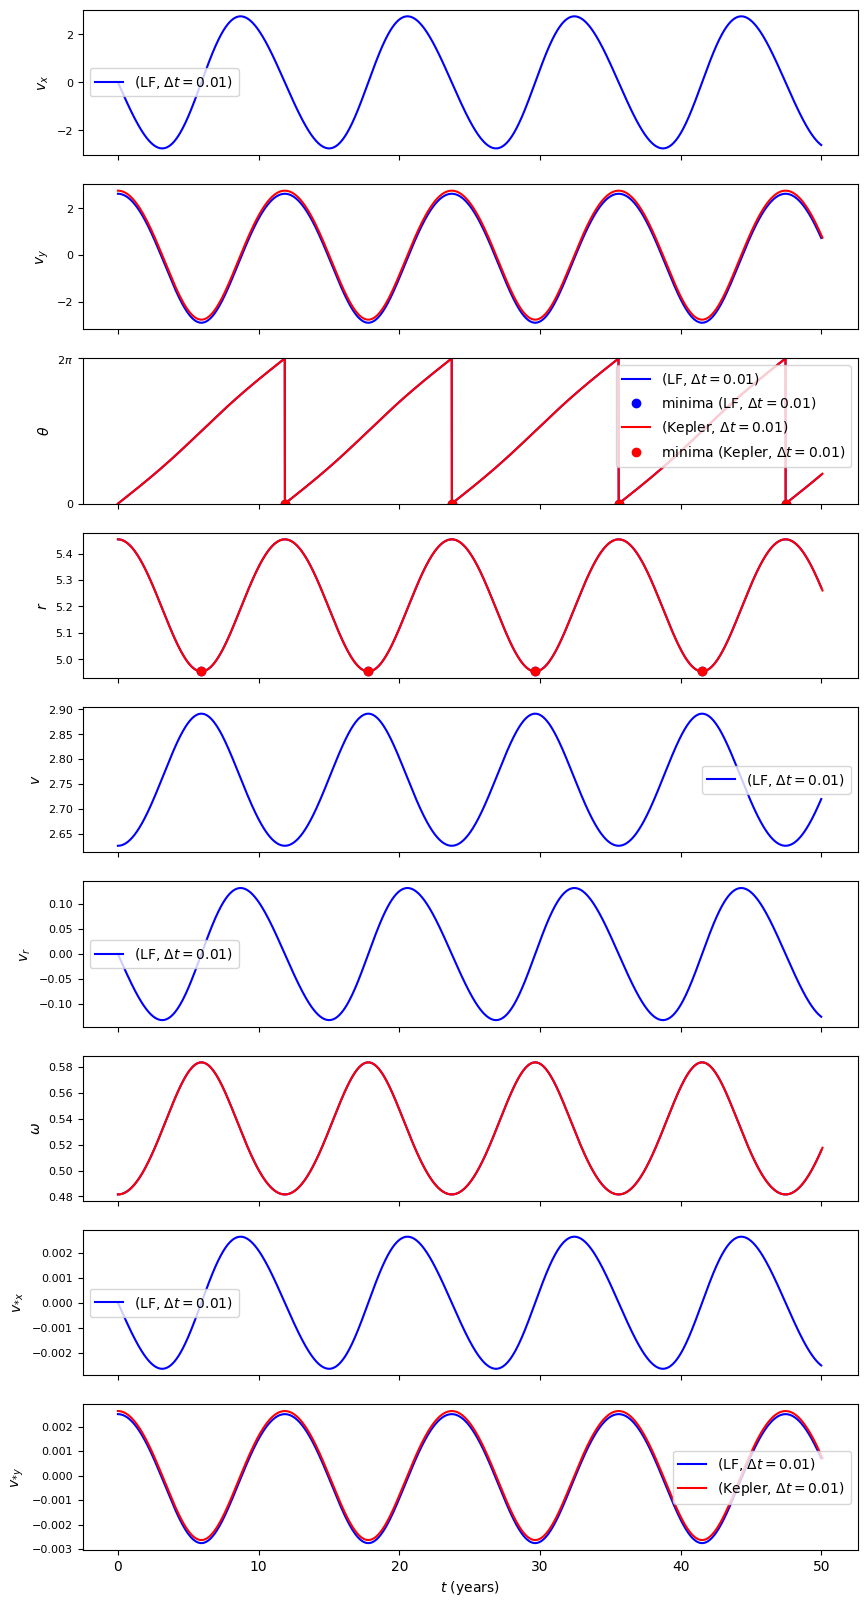

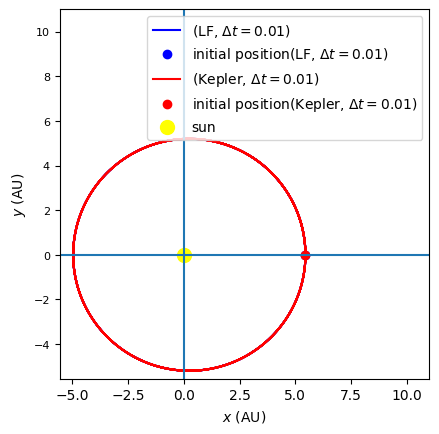

In [40]:
def Stellar_Wobble(
    GM=GM_s,
    m_by_M = 0.0009546, # for jupiter 
    methods = {"LF":0.01,"Kepler":0.01},
    T_max = 50, # years
    a = 5.204, # AU
    e = 0.048,
    vis=False
    ):
    r_init = a*(1+e)
    T = 2*np.pi*((a**3)/(GM*(1+m_by_M)))**0.5
    v_init = (2*np.pi*a / T)*(((1-e)/(1+e))**0.5)

    print(f"r_a = {r_init:.2f}, T_orb = {T:.2f}, v_a = {v_init:.2f}")
    r_init = np.array([r_init,0])
    v_init = np.array([0,v_init])

    if vis:
        fig = plt.figure(figsize=(10,20))
        AX = fig.subplots(9,1,sharex=True)
        fig2 = plt.figure()
        AX2 = fig2.subplots(1,1)
    colors = ["blue","red","green","black","purple","yellow","brown"][::-1]

    for method, dt in methods.items():
                if vis: c = colors.pop()
                t = np.arange(0,T_max+dt/2,dt)
                r = np.zeros((t.shape[0],2))
                v = np.zeros((t.shape[0],2))
                r[0] = r_init
                v[0] = v_init
                if method=="LF":
                    for i in range(t.shape[0]-1):
                        LF_step(r,v,gravity,dt,i,GM=GM*(1 + m_by_M))
                elif method=="LFTT":
                    W = np.zeros_like(t)
                    W[0] = 1/np.linalg.norm(r_init)
                    for i in range(t.shape[0]-1):
                        LFTT_step(W,t,r,v,gravity,dt,i,GM = GM*(1 + m_by_M))
                elif method=="LFAS":
                    for i in range(t.shape[0]-1):
                        LF_adaptive_step(t,r,v,gravity,dt,i,GM = GM*(1 + m_by_M))
                elif method=="Kepler":
                    psi = t * (2*np.pi/T)
                    t = T * (psi + e * np.sin(psi)) / (2*np.pi)
                    ctheta = (e + np.cos(psi))/(1 + e*np.cos(psi))
                    tthetaby2 = ((1-e)/(1+e))**0.5 * np.tan(psi/2)
                    stheta = 2*tthetaby2/(1 + tthetaby2**2)
                    r = a*(1-e*e)/(1-e*ctheta)
                    b = a*(1-e*e)**0.5
                    omega = (2*np.pi*a*b)/(T*(r**2))
                    theta = np.arctan2(stheta,ctheta)
                    theta = theta + (theta < 0)*2*np.pi
                    x = r*ctheta
                    y = r*stheta
                    v_y = (2*np.pi*a*a/(T*b))*ctheta
                    v_star_y = v_y * (m_by_M/(1 + m_by_M))

                else: raise ValueError(f"unknown method: {method}")
                if method != "Kepler":
                    x = r[:,0]
                    y = r[:,1]
                    v_x = v[:,0]
                    v_y = v[:,1]
                    v_star = v * m_by_M / (1 + m_by_M)
                    v_star_x = v_star[:,0]
                    v_star_y = v_star[:,1]
                    theta = np.arctan2(y,x)
                    theta = theta + 2*np.pi*(theta <  0)
                    r = (x**2 + y**2)**0.5
                    v = (v_x**2 + v_y**2)**0.5
                    v_theta = (-y*v_x + x*v_y)/r
                    omega = v_theta/r
                    v_r = (x*v_x + y*v_y)/r

                r_prev = np.concatenate((r[:1],r[:-1]))
                r_next = np.concatenate((r[1:],r[-1:]-1e-12))
                i_r = np.flatnonzero((r < r_prev) & (r <= r_next))
                theta_prev = np.concatenate((theta[:1],theta[:-1]))
                theta_next = np.concatenate((theta[1:],theta[-1:]))
                i_theta = np.flatnonzero((theta < theta_prev) & (theta <= theta_next))
                n_r = np.zeros_like(t,dtype=int)
                for i in i_r :
                    n_r = n_r + (np.arange(t.shape[0]) >= i)
                n_theta = np.zeros_like(t,dtype=int)
                for i in i_theta :
                    n_theta = n_theta + (np.arange(t.shape[0]) >= i)
                cond = (f"({method}," + r" $\Delta t=" + str(dt) + "$)")

                if not vis:continue
                if method !="Kepler": AX[0].plot(t,v_x,label=cond,color=c) 
                AX[1].plot(t,v_y,label=cond,color=c)
                AX[2].plot(t,theta,label=cond,color=c)
                AX[2].plot(t[i_theta],theta[i_theta],'o',label="minima " + cond,color=c)
                AX[3].plot(t,r,label=cond,color=c)
                AX[3].plot(t[i_r],r[i_r],'o',label="minima " + cond,color=c)
                if method !="Kepler": AX[4].plot(t,v,label=cond,color=c)
                if method !="Kepler": AX[5].plot(t,v_r,label=cond,color=c)
                AX[6].plot(t,omega,label=cond,color=c)
                if method !="Kepler": AX[7].plot(t,v_star_x,label=cond,color=c)
                AX[8].plot(t,v_star_y,label=cond,color=c)

                AX2.plot(x,y,label=cond,color=c)
                AX2.plot(x[0],y[0],'o',label="initial position" + cond,color=c)

    if vis:
        AX[2].set_ylim(0,2*np.pi)
        AX[2].set_yticks([0,2*np.pi],[0,r"$2\pi$"])
        AX[0].legend()
        AX[4].legend()
        AX[5].legend()
        AX[2].legend()
        AX[7].legend()
        AX[8].legend()
        ylabels = [
            "v_x","v_y",
            r"\theta","r",
            "v","v_r",
            r"\omega",
            r"v_{*x}",r"v_{*y}"]
        for ax,lbl in zip(AX,ylabels): 
            ax.set_ylabel("$" + lbl + "$")

        AX[8].set_xlabel(r"$t$ (years)")

        AX2.set_xlabel("$x$ (AU)")
        AX2.set_ylabel("$y$ (AU)")
        AX2.plot([0],[0],'o',label="sun",color="yellow",markersize=10)
        AX2.axhline(0)
        AX2.axvline(0)
        AX2.set_aspect('equal')
        AX2.set_xlim(-0.1-np.linalg.norm(r_init),0.1+2*np.linalg.norm(r_init))
        AX2.set_ylim(-0.1-np.linalg.norm(r_init),0.1+2*np.linalg.norm(r_init))
        AX2.legend()
    return t, theta

t,theta = Stellar_Wobble(vis=True)

### Part B : RV curve

r_a = 5.45, T_orb = 11.87, v_a = 2.63
r_a = 8.33, T_orb = 11.87, v_a = 1.38
r_a = 5.45, T_orb = 11.87, v_a = 2.63
r_a = 8.33, T_orb = 11.87, v_a = 1.38


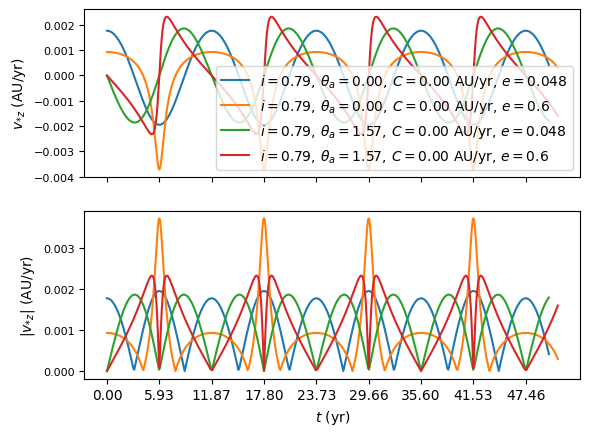

In [41]:
a = 5.204 # AU
m_by_M = 0.0009546 # for jupiter 
GM = 4*np.pi**2
T = 2*np.pi*((a**3)/(GM*(1+m_by_M)))**0.5
fig = plt.figure()
ax1,ax2 = fig.subplots(2,1, sharex=True)
for (i,theta_a,C,e) in [
    (np.pi/4,0,0,0.048),
    (np.pi/4,0,0,0.6),
    (np.pi/4,np.pi/2,0,0.048),
    (np.pi/4,np.pi/2,0,0.6),
    ]:
    t, theta = Stellar_Wobble(vis=False,a=a,e=e,m_by_M=m_by_M,GM=GM,methods={"Kepler":0.1})
    gamma = (m_by_M/(1 + m_by_M)) * (2*np.pi*a/(T*((1-e**2)**0.5))) * np.sin(i)
    v_star_z = C + gamma * (np.cos(theta + theta_a) - e*np.cos(theta_a))
    ax1.plot(t,v_star_z,label=f"$i = {i:.2f}, \,"+ r"\theta_a = " + f"{theta_a:.2f} , \, C = {C:.2f}$ AU/yr, $e = {e}$")
    ax2.plot(t,np.abs(v_star_z),label=f"$i = {i:.2f}, \,"+ r"\theta_a = " + f"{theta_a:.2f} , \, C = {C:.2f}$ AU/yr, $e = {e}$")
ax1.legend()
ax1.set_ylabel(r"$v_{*z}$ (AU/yr)")
ax2.set_ylabel(r"$|v_{*z}|$ (AU/yr)")
ax2.set_xlabel("$t$ (yr)")
ax2.set_xticks(np.arange(0,t[-1]+T/8,T/2))
plt.show()

The cases with a lower eccentricity (0.048) have a more sinusoidal shape, whereas those with high eccentricity (0.6) have regions of sudden change and other regions where there is not a lot of change. The nature of these changes are affected by the aphelion position $\theta_a$ too, wherease for the lower eccentricity cases, changing $\theta_a$ only shifts the plot to left or right. 

### Part C : Synthetic dataset with noise

r_a = 5.45, T_orb = 11.87, v_a = 2.63


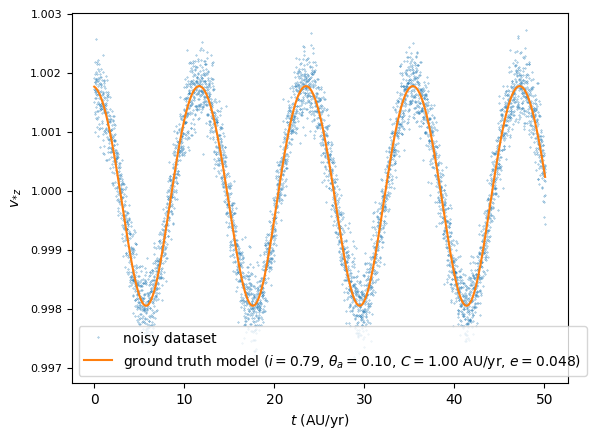

In [42]:
a = 5.204 # AU
m_by_M = 0.0009546 # for jupiter 
GM = 4*np.pi**2
i = np.pi/4
theta_a = 0.1 # rad
C = 1 # AU/year
e = 0.048 # for jupiter
T = 2*np.pi*((a**3)/(GM*(1+m_by_M)))**0.5
t, theta = Stellar_Wobble(vis=False,a=a,e=e,m_by_M=m_by_M,GM=GM,methods={"Kepler":0.01})
gamma = (m_by_M/(1 + m_by_M)) * (2*np.pi*a/(T*((1-e**2)**0.5))) * np.sin(i)
v_star_z = C + gamma * (np.cos(theta + theta_a) - e*np.cos(theta_a))
noise = np.random.normal(0,0.25*v_star_z.std(),theta.shape)
v_star_z_noisy = v_star_z + noise
lbl = label=f"$i = {i:.2f}, \,"+ r"\theta_a = " + f"{theta_a:.2f} , \, C = {C:.2f}$ AU/yr, $e = {e}$"
plt.plot(t,v_star_z_noisy,'o',label="noisy dataset", markersize=0.3,alpha=0.8)
plt.plot(t,v_star_z,'-',label=f"ground truth model ({lbl})")
plt.xlabel("$t$ (AU/yr)")
plt.ylabel(r"$v_{*z}$")
plt.legend()
plt.show()

### Part D : Parameter recovery

We will only use $t$ and `v_star_z_noisy` from last code cell, and the orbital period $T$ which can be estimated fairly accurately from other observation. The model is 

$$
t(\psi) = \frac{T}{2\pi}(\psi + e \sin\psi) \\
\cos\theta(\psi) = \frac{e + \cos\psi}{1 + e\cos\psi} \\ \tan(\theta/2) = \sqrt{(1-e)/(1+e)}\tan(\psi/2) \\
v_{*z} = \gamma(\cos(\theta + \theta_a) - e\cos\theta_a)
$$

We want to get $e, T, \gamma$ from the dataset consisting of $(t,v_{*z})$ pairs.

The books suggests using a "visual fitting" approach. I do not wish to do that. Instead, for each $T,e$,  first I will estimate $\psi(t)$ using a numerical method, such as the Newton-Ralphson method, and then fit compute $\cos(\theta)$ and $\sin(\theta)$ (by first computing $\tan(\theta/2)$) using $\psi$. This part won't involve using the noisy $v_{*z}$ values and will be fairly accurate. 
Then, I will simply compute $\cos(\theta)$ and $\sin(\theta)$ and do a least-squares regression to get the values of $\gamma$ and the RMSE for the regression. I will do this for many $(e,T)$ pairs. The one that gives least RMSE will be the one I will use. 

In [43]:
log_e = np.linspace(-6,0,30,endpoint=False)
e = 10**log_e
log_T = np.linspace(-1,2,30)
T = 10**log_T
e_mesh, T_mesh, t_mesh = np.meshgrid(e,T,t)
M = 2*np.pi*t_mesh/T_mesh
# Newton Ralphson
psi = M
for i in range(100):
    psi = psi - (psi + e_mesh*np.sin(psi) - M)/(1 + e_mesh*np.cos(psi))
print(psi.shape)
M_pred = psi + e_mesh*np.sin(psi)
ae = np.abs(M - M_pred)
print(ae.min(), ae.mean(),ae.max())

(30, 30, 5001)
0.0 7.554149371114701e-16 4.547473508864641e-13


As you can see, the Netwon Ralphson method is producing very little error, with the maximum error of only around $4.55\times 10^{-13} \text{ rad}$ for $M = \frac{2\pi}{T} t$

In [44]:
ctheta = (e_mesh + np.cos(psi))/(1 + e_mesh*np.cos(psi))
tthetaby2 = ((1-e_mesh)/(1+e_mesh))**0.5 * np.tan(psi/2)
stheta = 2*tthetaby2/(1 + tthetaby2**2)

def OLS(i,j):
    t = t_mesh[i][j]
    c = ctheta[i][j]
    s = stheta[i][j]
    X = np.vstack((c,s,np.ones_like(t))).T
    param,res,rk,_ = np.linalg.lstsq(X,v_star_z_noisy,rcond=None) 
    assert rk >= 3,(rk, X[:5])
    if len(res.shape) == 0 : res = 0
    else: res = res[0]
    return (res,param,i,j)

res,param,i,j = min(
    min(OLS(i,j) for i in range(t_mesh.shape[0])) 
    for j in range(t_mesh.shape[1])
)
e_best = e_mesh[i][j][0]
T_best = T_mesh[i][j][0]
gamma = (param[0]**2 + param[1]**2)**0.5
print(1 - (res/v_star_z_noisy.shape[0])/v_star_z_noisy.var())

0.9353308087530586


The $R^2$ goodness of fit value for the best regression is (as visible) around 0.93. This is an acceptable value. 

In [45]:
print("estimate for e :",round(e_best,4))
print("estimate for T :",round(T_best,4))
print("estimate for gamma :", round(gamma,4)) 

estimate for e : 0.0398
estimate for T : 11.721
estimate for gamma : 0.0019


Although not perfect, this resolution is acceptable to get only the lower limit of mass of the planet 

$$
\frac{m}{M} < \frac{m}{M}\sin i \approx \sqrt{1- e^2} (\frac{T}{2\pi GM})^{1/3} \gamma
$$

In [46]:
(1-e_best**2)*((T_best/ (2*np.pi * GM_s))**(1/3))*gamma

0.0006715424334120113

The actual value of $m/M$ for Jupiter is around 0.0009546. Considering that in our case we have $i = \pi/4$, the actual value of $\frac{m}{M}\sin i$ is around 0.000675

Thus, our estimate for $m\sin i$ is accurate. 

In [47]:
m_by_M * np.sin(np.pi/4)

0.0006750041333206782